Abordagem não supervisionada: utilização do corpus financeiro completo para exploração de padrões, agrupamentos e identificação de possíveis observações atípicas.

# 🚀 Configuração do Ambiente

Este notebook faz parte do projeto **FinCheck**.

Para executar o notebook localmente, siga os passos abaixo.

---

## 1. Clonar o repositório

No terminal:

```bash
git clone https://github.com/SEU-USUARIO/FinCheck.git
```

## Entre na pasta do projeto:
cd FinCheck

## Crie o ambiente virtual
```bash
python -m venv .venv
```
O ambiente virtual não é versionado no GitHub. Cada usuário deve criar seu próprio ambiente localmente.

## Ative o ambiente virtual:
```bash
source .venv/Scripts/activate
```
Após a ativação, o terminal deverá apresentar algo semelhante a:
(.venv)

## Instalar as dependências
```bash
pip install -r requirements.txt
```

## Verificar as principais dependências
```bash
python -c "import pandas, numpy, sklearn, matplotlib, seaborn, nltk, wordcloud; print('Todas as dependencias principais OK!')"
```

## Verificar o Jupyter
```bash
jupyter --version
```

## Executar pelo VS Code

Caso esteja utilizando o VS Code:

Abra a pasta FinCheck.
Abra o arquivo .ipynb.
Selecione o Kernel/Interpretador Python.
Escolha o ambiente: (.venv) ou .venv/Scripts/python.exe

## Observação:
A pasta .venv/ não deve ser enviada para o GitHub.
O arquivo requirements.txt deve ser enviado para o GitHub.
Os notebooks .ipynb devem ser enviados para o GitHub.
Consulte o README.md para informações adicionais sobre os datasets utilizados pelo projeto.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn
import nltk

from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import DBSCAN, KMeans, MiniBatchKMeans
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD
from nltk.corpus import stopwords


nltk.download("stopwords")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Jonat\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
url = "https://huggingface.co/datasets/lucasalmda/pt-br-financial-news-dataset/resolve/main/financial_news_br.jsonl"

finews = pd.read_json(url, lines=True)

print("Dataset carregado com sucesso!")
print("Dimensões:", finews.shape)

Dataset carregado com sucesso!
Dimensões: (56498, 10)


In [3]:
display(finews.head())

,source,url,published_at,week_key,week_start,week_end,tags,title,description,sentiment_text
0,Valor Econômico,https://valor.globo.com/brasil/noticia/2016/01...,2016-01-04 17:24:13+00:00,2016-W01,2016-01-04,2016-01-10,"[paulo picchetti, inflação, ipc-s (índice de p...","Inércia vai elevar inflação a 7,3% em 2016, av...",NaN,"Titulo: Inércia vai elevar inflação a 7,3% em ..."
1,Valor Econômico,https://valor.globo.com/brasil/noticia/2016/01...,2016-01-04 09:00:01+00:00,2016-W01,2016-01-04,2016-01-10,"[fabio romão, thiago curado, maurício nakahodo...","Serviços vão pressionar menos, mas IPCA ficará...",NaN,"Titulo: Serviços vão pressionar menos, mas IPC..."
2,InfoMoney,https://www.infomoney.com.br/mercados/petrobra...,2016-01-04 10:04:00+00:00,2016-W01,2016-01-04,2016-01-10,[],Petrobras vira e sobe 2%; Vale e siderúrgicas ...,NaN,Titulo: Petrobras vira e sobe 2%; Vale e sider...
3,InfoMoney,https://www.infomoney.com.br/mercados/presenca...,2016-01-04 11:55:00+00:00,2016-W01,2016-01-04,2016-01-10,[],Presença de Murilo Ferreira na Petrobras incom...,Parte do mercado se mostrou incomodada com o f...,Titulo: Presença de Murilo Ferreira na Petrobr...
4,Valor Econômico,https://valor.globo.com/financas/noticia/2016/...,2016-01-04 13:45:25+00:00,2016-W01,2016-01-04,2016-01-10,"[dilma rousseff, dólar, moeda (unidade monetár...","Dólar reduz alta, mas continua acima de R$ 4",NaN,"Titulo: Dólar reduz alta, mas continua acima d..."


In [4]:
print("Colunas:")
print(finews.columns.tolist())

Colunas:
['source', 'url', 'published_at', 'week_key', 'week_start', 'week_end', 'tags', 'title', 'description', 'sentiment_text']


In [5]:
print(finews["source"].value_counts())

source
Valor Econômico    31682
InfoMoney          15998
Exame               8818
Name: count, dtype: int64


In [6]:
print(finews.isnull().sum())

source                0
url                   0
published_at          0
week_key              0
week_start            0
week_end              0
tags                  0
title                 0
description       36718
sentiment_text        0
dtype: int64


In [7]:
print("Total de notícias:", len(finews))
print("Com descrição:", finews["description"].notna().sum())
print("Sem descrição:", finews["description"].isna().sum())

Total de notícias: 56498
Com descrição: 19780
Sem descrição: 36718


In [8]:
finews_limpo = finews.dropna(subset=["description"]).copy()

print("Dimensões após a limpeza:", finews_limpo.shape)
print("Descrições nulas:", finews_limpo["description"].isnull().sum())

Dimensões após a limpeza: (19780, 10)
Descrições nulas: 0


In [9]:
print("Títulos duplicados:", finews_limpo["title"].duplicated().sum())
print("URLs duplicadas:", finews_limpo["url"].duplicated().sum())
print(
    "Título + descrição duplicados:",
    finews_limpo.duplicated(subset=["title", "description"]).sum()
)

Títulos duplicados: 82
URLs duplicadas: 0
Título + descrição duplicados: 30


In [10]:
finews_limpo = finews_limpo.drop_duplicates(
    subset=["title", "description"]
).copy()

print("Dimensões após remover duplicatas:", finews_limpo.shape)

Dimensões após remover duplicatas: (19750, 10)


In [11]:
os.makedirs("../data/processed", exist_ok=True)

print("Pasta processed verificada/criada.")

Pasta processed verificada/criada.


In [12]:
caminho_saida = "../data/processed/financial_news_br_limpo.csv"

finews_limpo.to_csv(
    caminho_saida,
    index=False,
    encoding="utf-8-sig"
)

print("Dataset salvo com sucesso!")
print("Caminho:", caminho_saida)
print("Dimensões:", finews_limpo.shape)

Dataset salvo com sucesso!
Caminho: ../data/processed/financial_news_br_limpo.csv
Dimensões: (19750, 10)


EDA -> Análise Exploratória de Dados

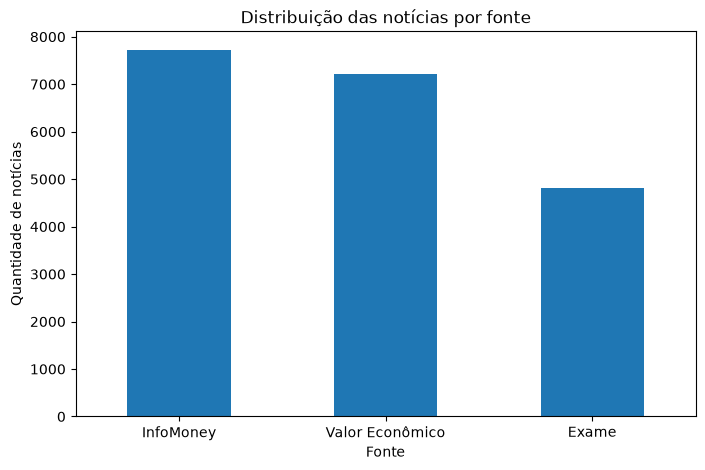

In [13]:
finews_limpo["source"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Distribuição das notícias por fonte")
plt.xlabel("Fonte")
plt.ylabel("Quantidade de notícias")
plt.xticks(rotation=0)

plt.show()

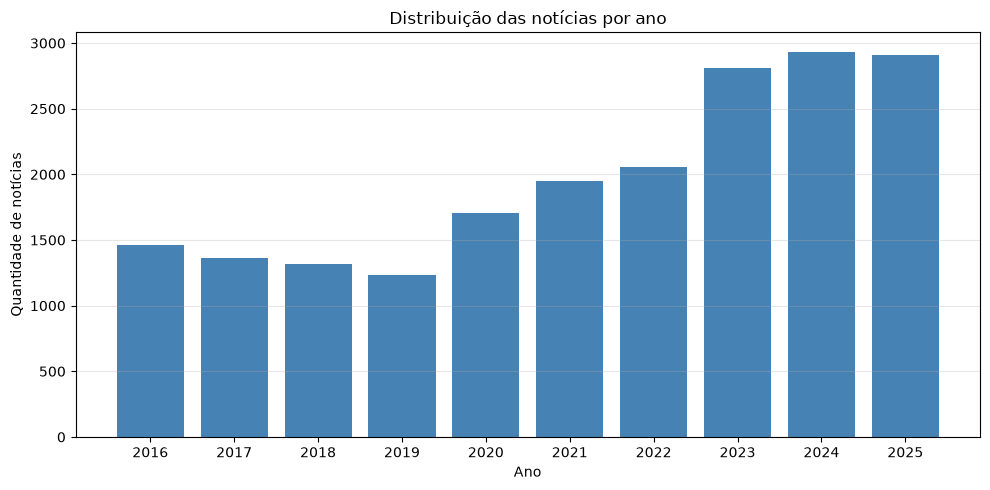

In [14]:
finews_limpo["published_at"] = pd.to_datetime(
    finews_limpo["published_at"],
    errors="coerce"
)
finews_limpo["published_at"].describe()
finews_limpo["year"] = finews_limpo["published_at"].dt.year
finews_limpo["year"].value_counts().sort_index()

contagem = finews_limpo["year"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(contagem.index, contagem.values, color="steelblue")  # ou plt.plot(...)
plt.title("Distribuição das notícias por ano")
plt.xlabel("Ano")
plt.ylabel("Quantidade de notícias")
plt.xticks(contagem.index, rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

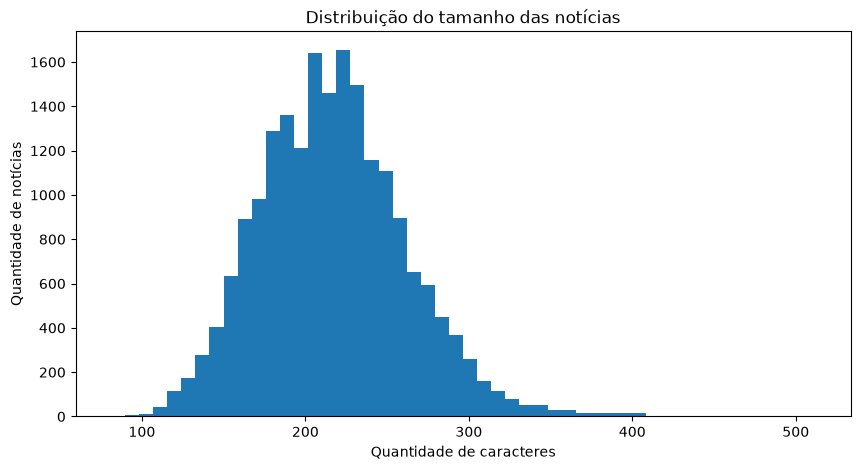

In [15]:
# ============================================================
# VARIÁVEIS PARA A ANÁLISE TEXTUAL
# ============================================================

finews_limpo["published_at"] = pd.to_datetime(
    finews_limpo["published_at"],
    errors="coerce"
)

finews_limpo["year"] = finews_limpo["published_at"].dt.year

finews_limpo["title_chars"] = (
    finews_limpo["title"]
    .fillna("")
    .astype(str)
    .str.len()
)

finews_limpo["text_chars"] = (
    finews_limpo["sentiment_text"]
    .fillna("")
    .astype(str)
    .str.len()
)

finews_limpo["title_words"] = (
    finews_limpo["title"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

finews_limpo["text_words"] = (
    finews_limpo["sentiment_text"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

plt.figure(figsize=(10, 5))

plt.hist(
    finews_limpo["text_chars"],
    bins=50
)

plt.title("Distribuição do tamanho das notícias")
plt.xlabel("Quantidade de caracteres")
plt.ylabel("Quantidade de notícias")

plt.show()

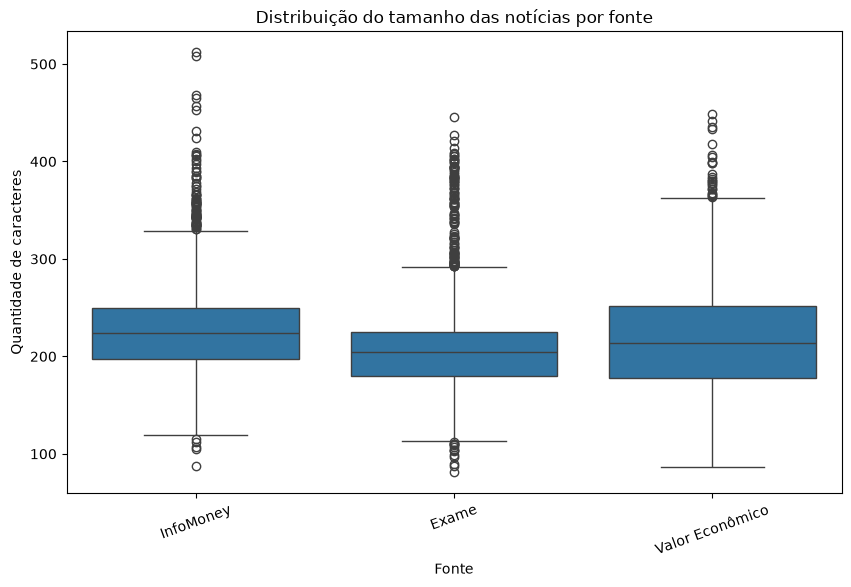

In [16]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=finews_limpo,
    x="source",
    y="text_chars"
)

plt.title("Distribuição do tamanho das notícias por fonte")
plt.xlabel("Fonte")
plt.ylabel("Quantidade de caracteres")

plt.xticks(rotation=20)

plt.show()

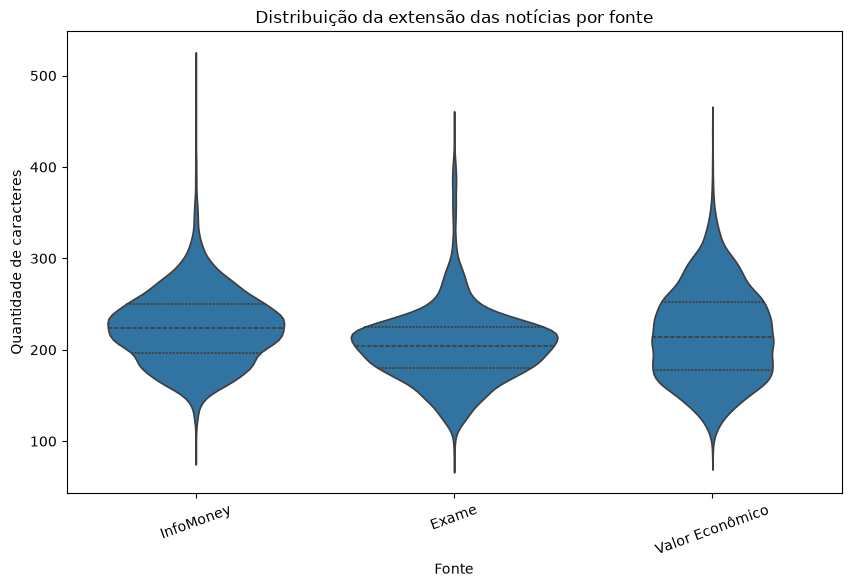

In [17]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=finews_limpo,
    x="source",
    y="text_chars",
    inner="quartile"
)

plt.title("Distribuição da extensão das notícias por fonte")
plt.xlabel("Fonte")
plt.ylabel("Quantidade de caracteres")

plt.xticks(rotation=20)

plt.show()

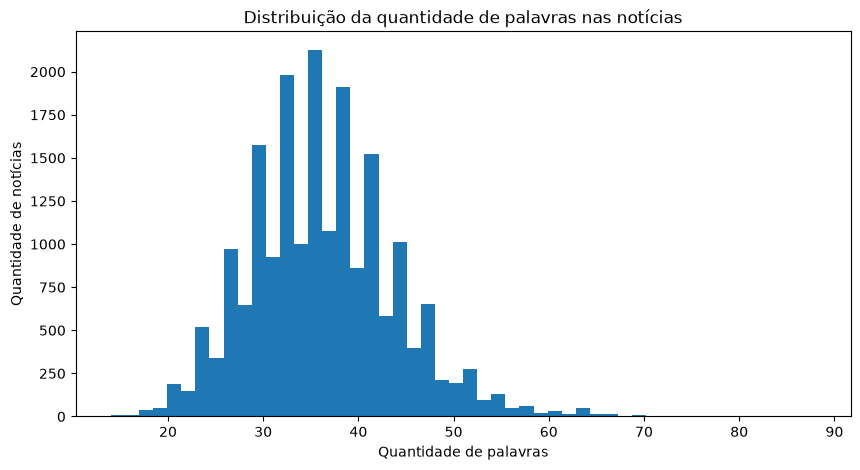

In [18]:
plt.figure(figsize=(10, 5))

plt.hist(
    finews_limpo["text_words"],
    bins=50
)

plt.title("Distribuição da quantidade de palavras nas notícias")
plt.xlabel("Quantidade de palavras")
plt.ylabel("Quantidade de notícias")

plt.show()

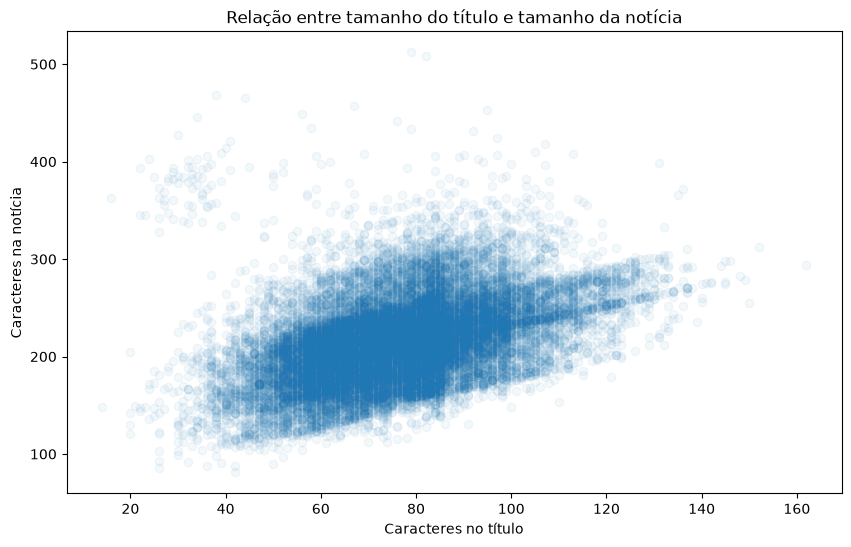

In [19]:
plt.figure(figsize=(10, 6))

plt.scatter(
    finews_limpo["title_chars"],
    finews_limpo["text_chars"],
    alpha=0.05
)

plt.title("Relação entre tamanho do título e tamanho da notícia")
plt.xlabel("Caracteres no título")
plt.ylabel("Caracteres na notícia")

plt.show()

In [20]:
finews_limpo["tags"].head(10)

3     []
5     []
8     []
10    []
11    []
14    []
16    []
18    []
30    []
33    []
Name: tags, dtype: object

In [21]:
from collections import Counter

todas_tags = []

for tags in finews_limpo["tags"].dropna():

    if isinstance(tags, list):
        todas_tags.extend(tags)

contador_tags = Counter(todas_tags)

tags_df = pd.DataFrame(
    contador_tags.most_common(20),
    columns=["tag", "quantidade"]
)

display(tags_df)

,tag,quantidade
0,inflação,2044
1,taxa selic,1550
2,brasil,1532
3,ibovespa,1314
4,copom,1226
5,política monetária,1161
6,dólar,1137
7,pib,1127
8,estados unidos,1122
9,banco central do brasil,1101


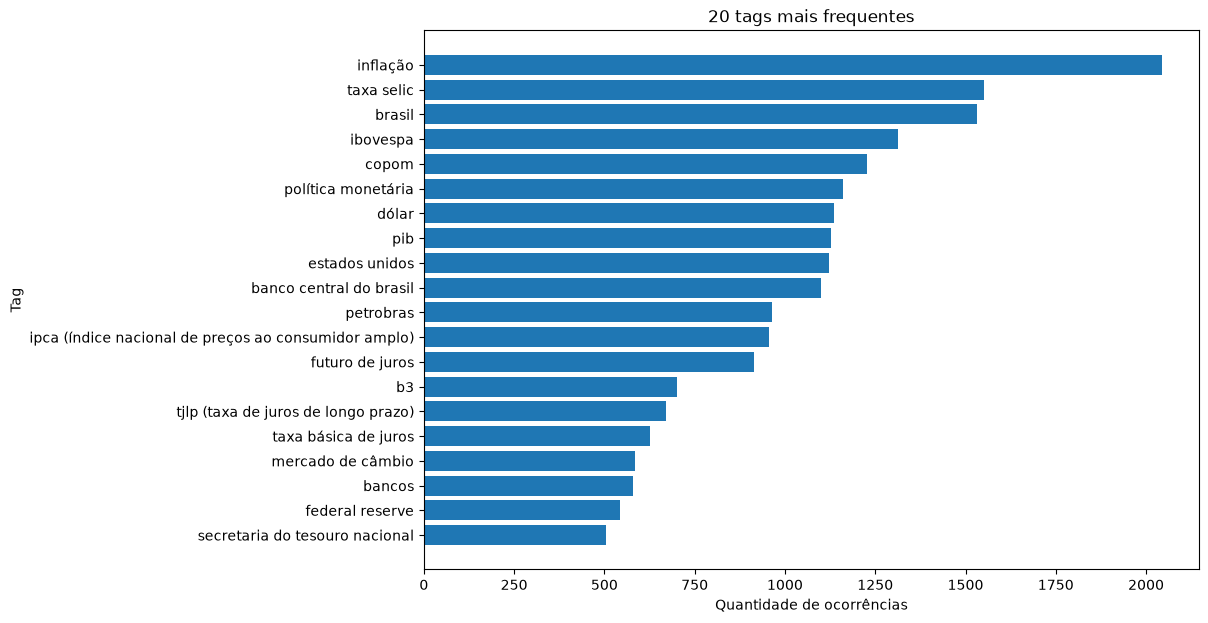

In [22]:
plt.figure(figsize=(10, 7))

plt.barh(
    tags_df["tag"][::-1],
    tags_df["quantidade"][::-1]
)

plt.title("20 tags mais frequentes")
plt.xlabel("Quantidade de ocorrências")
plt.ylabel("Tag")

plt.show()

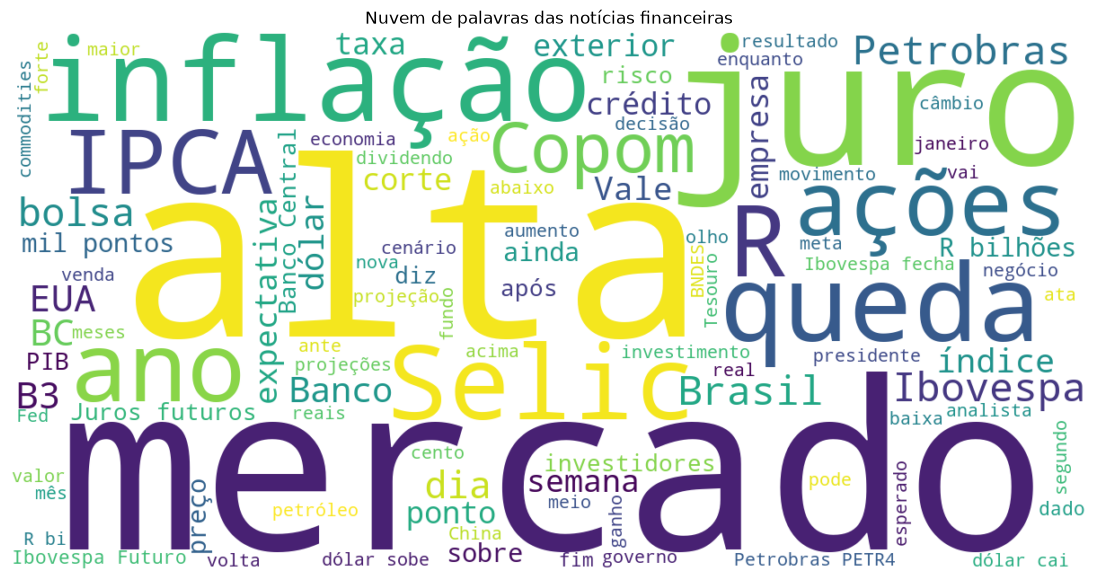

In [23]:
# Stopwords em português
stopwords_pt = set(stopwords.words("portuguese"))

# Junta título + descrição
texto = " ".join(
    finews_limpo["title"].fillna("") + " " +
    finews_limpo["description"].fillna("")
)

# Gera a nuvem
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=stopwords_pt,
    max_words=100
).generate(texto)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nuvem de palavras das notícias financeiras")
plt.show()

In [24]:
tags = finews_limpo["tags"].value_counts()

print(tags.head(20))

tags
[]                                                                              12585
[Mercados, Ações, Ao Vivo, Dólar, Ibovespa, Trader]                               201
[ibovespa]                                                                         88
[Mercados, Ações, Ao Vivo, Bolsa, Dólar, Ibovespa, Trader]                         70
[dólar]                                                                            44
[Mercados, Ações, Ao Vivo, Ibovespa, Trader]                                       21
[futuro de juros]                                                                  19
[b3, investidor estrangeiro, ibovespa, investidores institucionais]                18
[Mercados, Ações, Ao Vivo, Ibovespa, Nyse, Rússia, Ucrânia]                        17
[ipca-15, ibge]                                                                    15
[ipca (índice nacional de preços ao consumidor amplo), ibge]                       14
[sistema financeiro, banco central do brasil]    

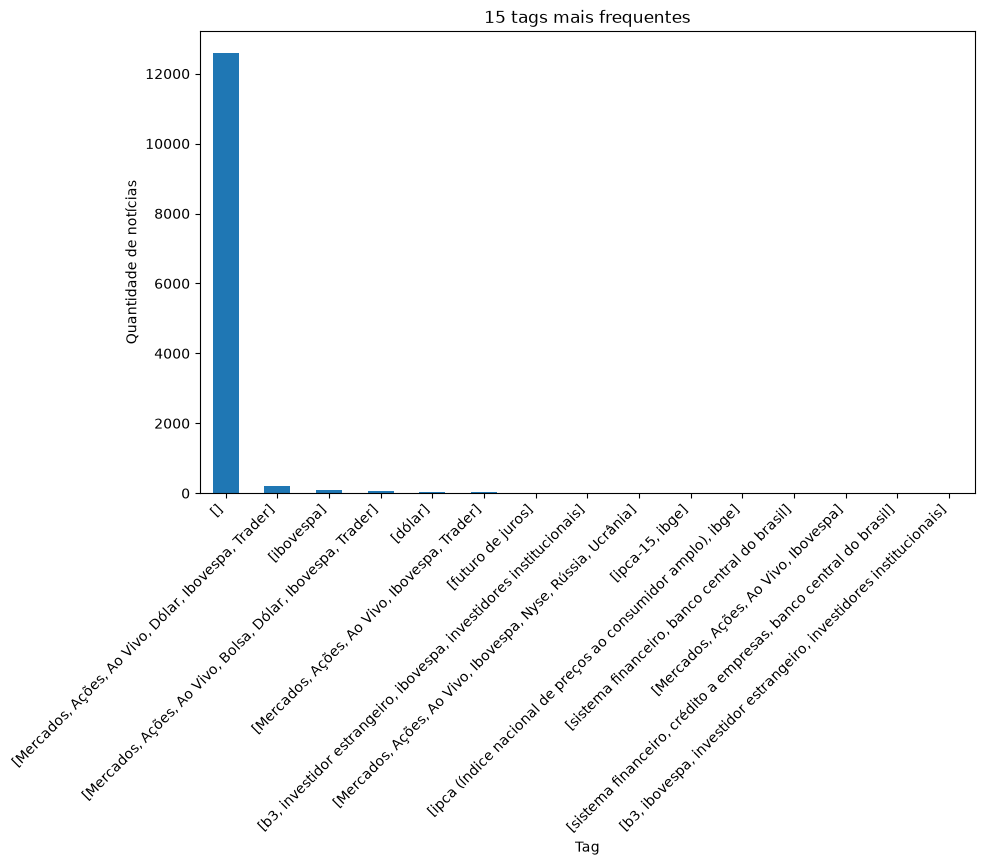

In [25]:
plt.figure(figsize=(10, 6))

tags.head(15).plot(
    kind="bar"
)

plt.title("15 tags mais frequentes")
plt.xlabel("Tag")
plt.ylabel("Quantidade de notícias")
plt.xticks(rotation=45, ha="right")

plt.show()

In [26]:
print(
    "Duplicatas de título:",
    finews_limpo["title"].duplicated().sum()
)

print(
    "Duplicatas de URL:",
    finews_limpo["url"].duplicated().sum()
)

print(
    "Duplicatas de título + descrição:",
    finews_limpo.duplicated(
        subset=["title", "description"]
    ).sum()
)

Duplicatas de título: 52
Duplicatas de URL: 0
Duplicatas de título + descrição: 0


In [27]:
finews_limpo[
    ["title_chars", "text_chars"]
].describe()

,title_chars,text_chars
count,19750.000000,19750.000000
mean,76.605266,217.171747
std,18.407793,45.114943
min,14.000000,81.000000
25%,64.000000,185.000000
50%,76.000000,215.000000
75%,88.000000,245.000000
max,162.000000,512.000000


In [28]:
finews_limpo.describe()

,year,title_chars,text_chars,title_words,text_words
count,19750.000000,19750.000000,19750.000000,19750.000000,19750.000000
mean,2021.365924,76.605266,217.171747,13.485570,36.334532
std,2.851379,18.407793,45.114943,3.414393,7.718052
min,2016.000000,14.000000,81.000000,3.000000,14.000000
25%,2019.000000,64.000000,185.000000,11.000000,31.000000
50%,2022.000000,76.000000,215.000000,13.000000,36.000000
75%,2024.000000,88.000000,245.000000,16.000000,41.000000
max,2025.000000,162.000000,512.000000,28.000000,88.000000


In [29]:
finews_limpo.describe(include="all")

,source,url,published_at,week_key,week_start,week_end,tags,title,description,sentiment_text,year,title_chars,text_chars,title_words,text_words
count,19750,19750,19750,19750,19750,19750,19750,19750,19750,19750,19750.000000,19750.000000,19750.000000,19750.000000,19750.000000
unique,3,19750,NaN,522,522,522,6382,19698,18897,19750,NaN,NaN,NaN,NaN,NaN
top,InfoMoney,https://www.infomoney.com.br/mercados/presenca...,NaN,2023-W31,2023-07-31,2023-08-06,[],Curtas – uma seleção do mais importante no Bra...,Tudo o que o investidor precisa saber antes de...,Titulo: Presença de Murilo Ferreira na Petrobr...,NaN,NaN,NaN,NaN,NaN
freq,7724,1,NaN,100,100,100,12585,8,120,1,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2021-11-13 02:38:21.087978+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021.365924,76.605266,217.171747,13.485570,36.334532
min,NaN,NaN,2016-01-04 08:36:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016.000000,14.000000,81.000000,3.000000,14.000000
25%,NaN,NaN,2019-10-01 17:08:53.799500+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,64.000000,185.000000,11.000000,31.000000
50%,NaN,NaN,2022-05-31 13:06:43.575500+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022.000000,76.000000,215.000000,13.000000,36.000000
75%,NaN,NaN,2024-04-22 08:02:42.256500+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024.000000,88.000000,245.000000,16.000000,41.000000
max,NaN,NaN,2025-12-31 10:58:29.049000+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025.000000,162.000000,512.000000,28.000000,88.000000


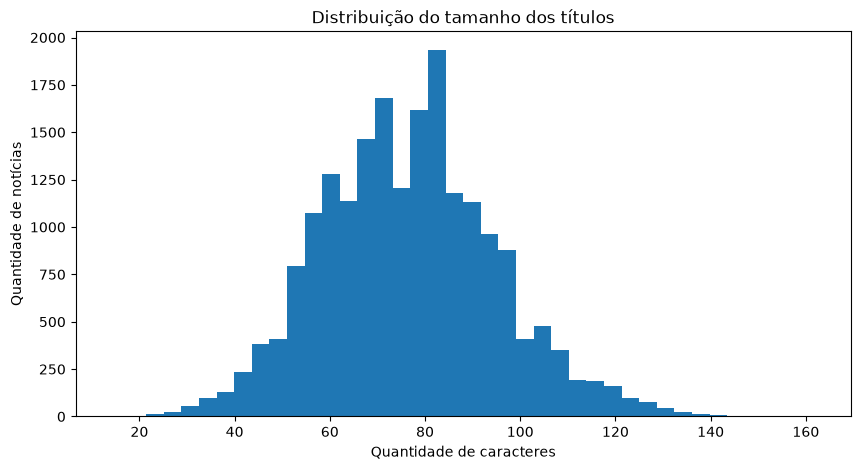

In [30]:
plt.figure(figsize=(10, 5))

plt.hist(
    finews_limpo["title_chars"],
    bins=40
)

plt.title("Distribuição do tamanho dos títulos")
plt.xlabel("Quantidade de caracteres")
plt.ylabel("Quantidade de notícias")

plt.show()

In [31]:
correlacao = finews_limpo[
    ["title_chars", "text_chars"]
].corr()

print(correlacao)

             title_chars  text_chars
title_chars     1.000000    0.424514
text_chars      0.424514    1.000000


In [32]:
finews_limpo.columns.tolist()

['source',
 'url',
 'published_at',
 'week_key',
 'week_start',
 'week_end',
 'tags',
 'title',
 'description',
 'sentiment_text',
 'year',
 'title_chars',
 'text_chars',
 'title_words',
 'text_words']

In [33]:
finews_limpo["text_clean"] = (
    finews_limpo["title"].fillna("") + " " +
    finews_limpo["description"].fillna("")
)

In [34]:
finews_limpo[["title", "description", "text_clean"]].head()

,title,description,text_clean
3,Presença de Murilo Ferreira na Petrobras incom...,Parte do mercado se mostrou incomodada com o f...,Presença de Murilo Ferreira na Petrobras incom...
5,"13 ações caem mais de 5%, Petrobras sobe 2% e ...",Confira os principais destaques de ações da Bo...,"13 ações caem mais de 5%, Petrobras sobe 2% e ..."
8,"Focus ""estreia"" 2016 projetando queda maior no...",A previsão de retração do PIB (Produto Interno...,"Focus ""estreia"" 2016 projetando queda maior no..."
10,Focus prevê mais inflação e maior retração eco...,"Apesar da expectativa de aperto monetário, a p...",Focus prevê mais inflação e maior retração eco...
11,"IPCA para 2016 sobe de 6,86% para 6,87%, apont...",Banco Central se propôs à tarefa de colocar a ...,"IPCA para 2016 sobe de 6,86% para 6,87%, apont..."


TF-IDF

In [35]:
# ============================================================
# TF-IDF
# ============================================================

tfidf_unsup = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    stop_words=list(stopwords_pt),
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    max_features=50000,
    sublinear_tf=True
)

X_tfidf = tfidf_unsup.fit_transform(
    finews_limpo["text_clean"]
)

print("Dimensão da matriz TF-IDF:")
print(X_tfidf.shape)

c:\Users\Jonat\Desktop\FinCheck\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:412: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ate', 'eramos', 'estao', 'estavamos', 'estiveramos', 'estivessemos', 'foramos', 'fossemos', 'ha', 'hao', 'houveramos', 'houverao', 'houveriamos', 'houvessemos', 'ja', 'nao', 'sao', 'sera', 'serao', 'seriamos', 'so', 'tambem', 'tera', 'terao', 'teriamos', 'tinhamos', 'tiveramos', 'tivessemos', 'voce', 'voces'] not in stop_words.
  warnings.warn(


Dimensão da matriz TF-IDF:
(19750, 17025)


Título:
Presença de Murilo Ferreira na Petrobras incomodou o mercado em 2015


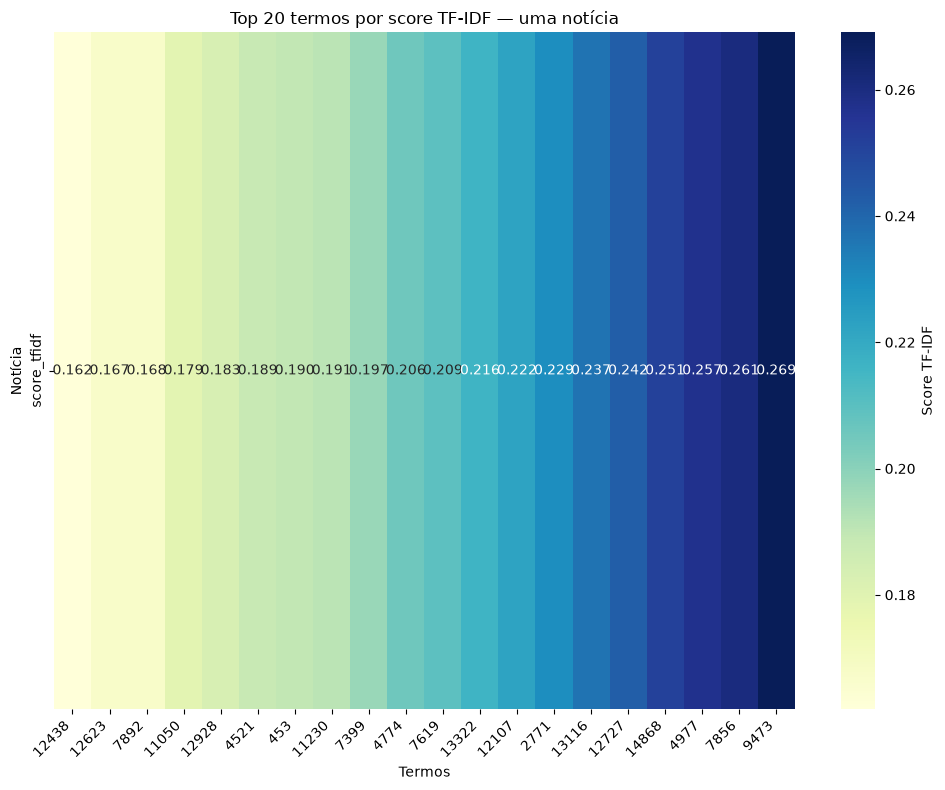

In [36]:
indice_noticia = 0

print("Título:")
print(finews_limpo.iloc[indice_noticia]["title"])

scores_noticia = X_tfidf[indice_noticia].toarray().ravel()

termos = tfidf_unsup.get_feature_names_out()

tfidf_noticia = pd.DataFrame({
    "termo": termos,
    "score_tfidf": scores_noticia
})

tfidf_noticia = tfidf_noticia[
    tfidf_noticia["score_tfidf"] > 0
]

top_noticia = (
    tfidf_noticia
    .sort_values("score_tfidf", ascending=False)
    .head(20)
    .sort_values("score_tfidf")
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    top_noticia[["score_tfidf"]].T,
    cmap="YlGnBu",
    annot=True,
    fmt=".3f",
    cbar_kws={"label": "Score TF-IDF"}
)

plt.title("Top 20 termos por score TF-IDF — uma notícia")
plt.xlabel("Termos")
plt.ylabel("Notícia")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

REDUÇÃO TF-IDF

In [37]:
svd = TruncatedSVD(
    n_components=100,
    random_state=42
)

X_reduced = svd.fit_transform(X_tfidf)

print("Dimensão após redução:")
print(X_reduced.shape)

Dimensão após redução:
(19750, 100)


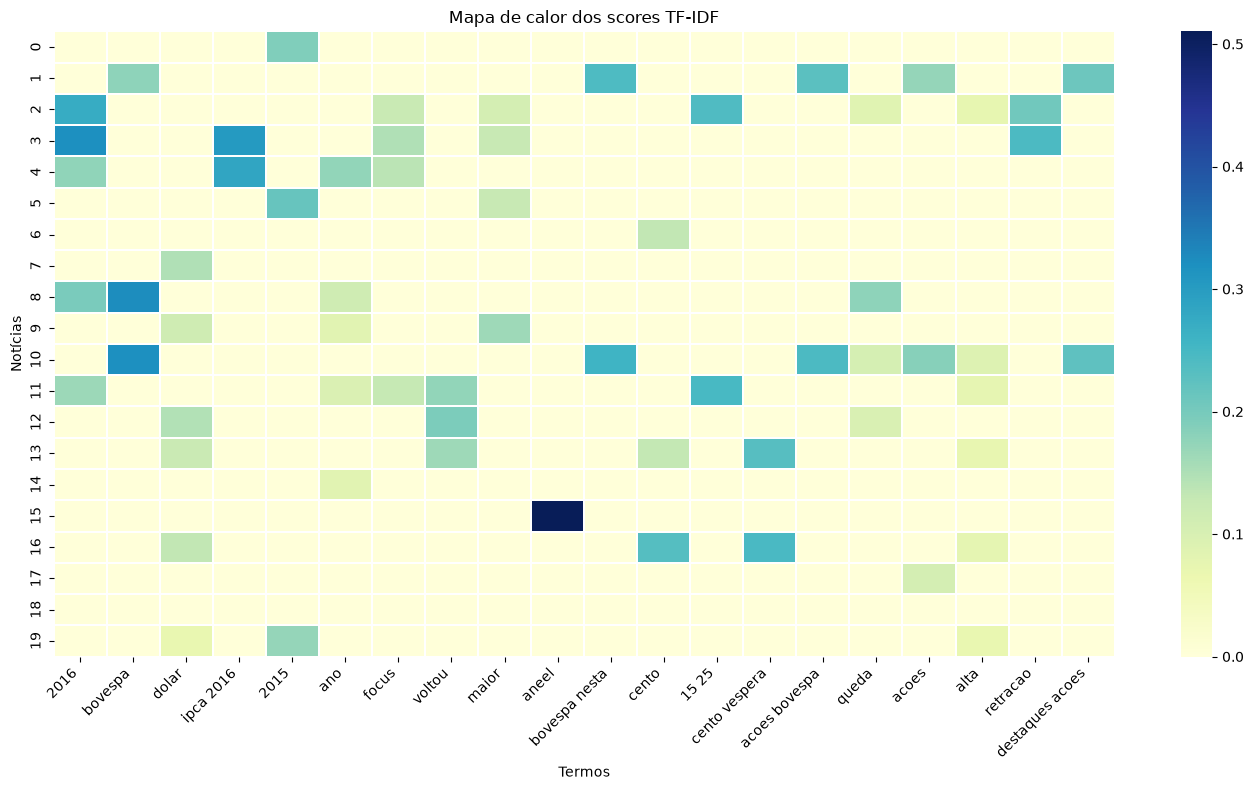

In [38]:
# 20 primeiras notícias
X_amostra = X_tfidf[:20]

# Converte para DataFrame
tfidf_amostra = pd.DataFrame(
    X_amostra.toarray(),
    columns=tfidf_unsup.get_feature_names_out()
)

# 20 termos com maior score na amostra
top_termos = (
    tfidf_amostra
    .sum(axis=0)
    .sort_values(ascending=False)
    .head(20)
    .index
)

heatmap_data = tfidf_amostra[top_termos]

plt.figure(figsize=(14, 8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.3
)

plt.title("Mapa de calor dos scores TF-IDF")
plt.xlabel("Termos")
plt.ylabel("Notícias")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Treinamento Não Supervisionado
kmeans

In [39]:
# Número de clusters
K_FINAL = 5

# Criando o modelo K-Means
kmeans = KMeans(
    n_clusters=K_FINAL,
    random_state=42,
    n_init=10
)

# Treinando o modelo e atribuindo os clusters
finews_limpo["cluster"] = kmeans.fit_predict(X_reduced)

# Distribuição das notícias por cluster
print("Distribuição dos clusters:")
print(
    finews_limpo["cluster"]
    .value_counts()
    .sort_index()
)

Distribuição dos clusters:
cluster
0     306
1    4882
2    8456
3    5925
4     181
Name: count, dtype: int64


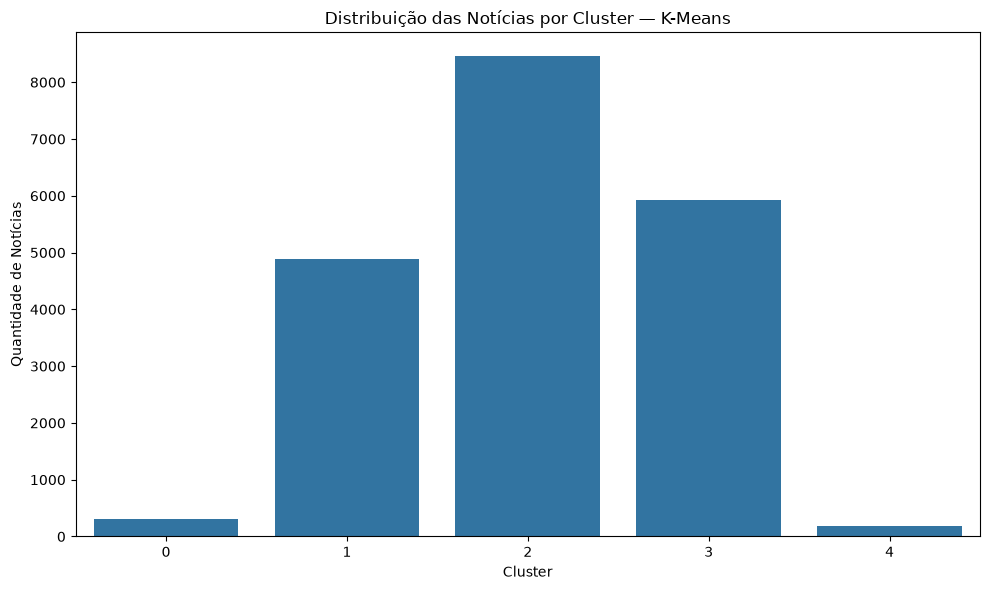

In [40]:
plt.figure(figsize=(10, 6))

contagem_kmeans = (
    finews_limpo["cluster"]
    .value_counts()
    .sort_index()
)

sns.barplot(
    x=contagem_kmeans.index,
    y=contagem_kmeans.values
)

plt.title("Distribuição das Notícias por Cluster — K-Means")
plt.xlabel("Cluster")
plt.ylabel("Quantidade de Notícias")

plt.tight_layout()
plt.show()

In [41]:
# Avaliação do agrupamento
silhouette = silhouette_score(
    X_reduced,
    finews_limpo["cluster"]
)

print(f"\nSilhouette Score: {silhouette:.4f}")


Silhouette Score: 0.0475


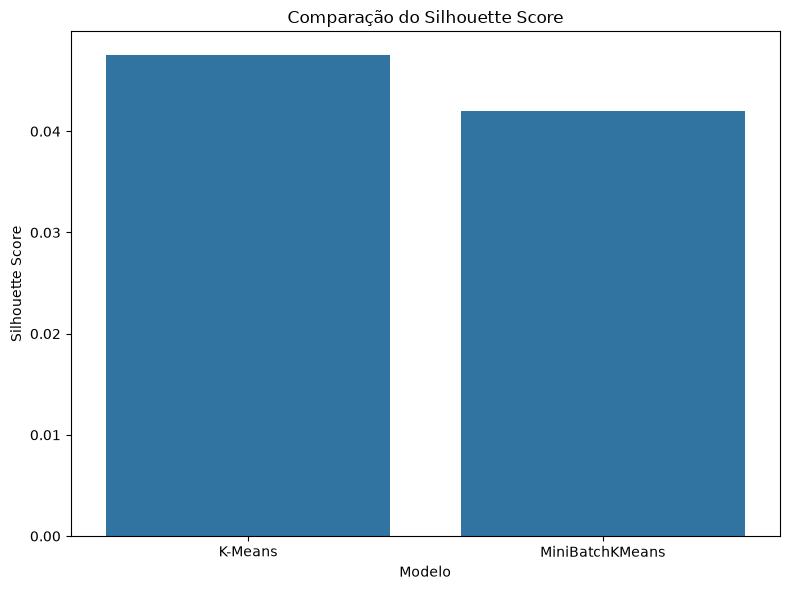

In [42]:
silhouette_comparacao = pd.DataFrame({
    "Modelo": ["K-Means", "MiniBatchKMeans"],
    "Silhouette": [0.0475, 0.0420]
})

plt.figure(figsize=(8, 6))

sns.barplot(
    data=silhouette_comparacao,
    x="Modelo",
    y="Silhouette"
)

plt.title("Comparação do Silhouette Score")
plt.xlabel("Modelo")
plt.ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

In [43]:
# Principais termos associados a cada cluster

termos = tfidf_unsup.get_feature_names_out()

for cluster in range(K_FINAL):

    noticias_cluster = finews_limpo["cluster"] == cluster

    # Média dos valores TF-IDF das notícias pertencentes ao cluster
    tfidf_cluster = X_tfidf[noticias_cluster.values]

    medias = tfidf_cluster.mean(axis=0).A1

    indices = medias.argsort()[::-1][:15]

    print(f"\nCluster {cluster}")
    print("-" * 50)
    print(", ".join(termos[i] for i in indices))


Cluster 0
--------------------------------------------------
acompanhe movimenta, commodities negocios, negocios pregao, acompanhe, bolsa, pregao desta, movimenta, juros commodities, bolsa acoes, acoes dolar, movimenta bolsa, negocios, commodities, dolar juros, pregao

Cluster 1
--------------------------------------------------
juros, selic, inflacao, copom, bc, mercado, taxa, ano, ipca, projecao, juros futuros, alta, futuros, focus, corte

Cluster 2
--------------------------------------------------
acoes, b3, petrobras, mercado, credito, bilhoes, brasil, diz, vale, bolsa, tesouro, ipca, bndes, nao, banco

Cluster 3
--------------------------------------------------
ibovespa, dolar, alta, pontos, queda, apos, fecha, sobe, cai, indice, exterior, mil, dia, futuro, mil pontos

Cluster 4
--------------------------------------------------
semana, tudo investidor, antes operar, saber antes, investidor precisa, precisa saber, operar semana, saber, semana tudo, tudo, operar, precisa, invest

In [44]:
# ============================================================
# REDUÇÃO PARA VISUALIZAÇÃO EM 2D
# ============================================================

svd_2d = TruncatedSVD(
    n_components=2,
    random_state=42
)

X_2d = svd_2d.fit_transform(X_tfidf)

print("Dimensão após redução:")
print(X_2d.shape)

Dimensão após redução:
(19750, 2)


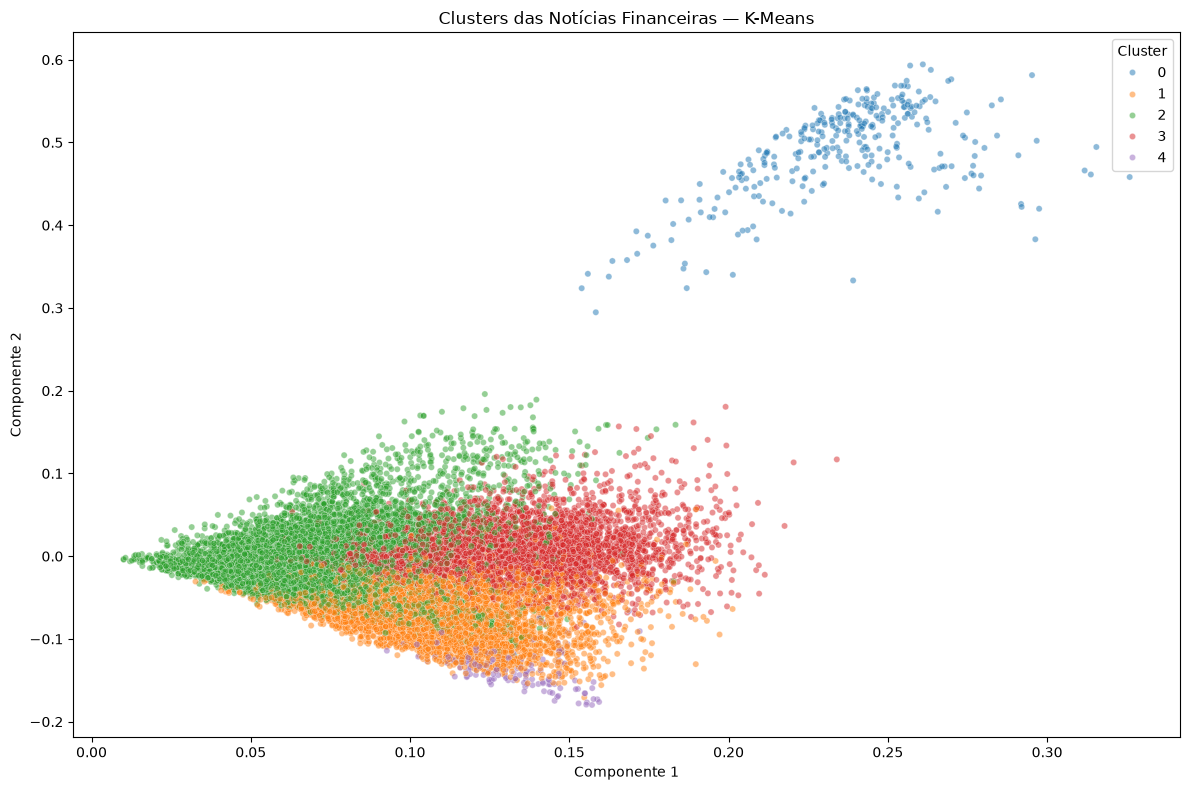

In [45]:
# ============================================================
# VISUALIZAÇÃO DOS CLUSTERS
# ============================================================

plt.figure(figsize=(12, 8))

sns.scatterplot(
    x=X_2d[:, 0],
    y=X_2d[:, 1],
    hue=finews_limpo["cluster"],
    palette="tab10",
    s=20,
    alpha=0.5,
    legend="full"
)

plt.title("Clusters das Notícias Financeiras — K-Means")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

MiniBatchKMeans

In [46]:
K_FINAL = 5

mbkmeans = MiniBatchKMeans(
    n_clusters=K_FINAL,
    random_state=42,
    batch_size=256,
    n_init=10
)

finews_limpo["cluster_mini"] = mbkmeans.fit_predict(
    X_reduced
)

print("Distribuição dos clusters — MiniBatchKMeans:")

print(
    finews_limpo["cluster_mini"]
    .value_counts()
    .sort_index()
)

Distribuição dos clusters — MiniBatchKMeans:
cluster_mini
0      102
1      698
2    17701
3      306
4      943
Name: count, dtype: int64


In [47]:
silhouette_mini = silhouette_score(
    X_reduced,
    finews_limpo["cluster_mini"]
)

print(f"Silhouette Score — MiniBatchKMeans: {silhouette_mini:.4f}")

Silhouette Score — MiniBatchKMeans: 0.0420


In [48]:
silhouette_kmeans = silhouette_score(
    X_reduced,
    finews_limpo["cluster"]
)

print(f"K-Means:        {silhouette_kmeans:.4f}")
print(f"MiniBatchKMeans: {silhouette_mini:.4f}")

K-Means:        0.0475
MiniBatchKMeans: 0.0420


In [49]:
comparacao_clusters = pd.DataFrame({
    "K-Means": finews_limpo["cluster"].value_counts().sort_index(),
    "MiniBatchKMeans": finews_limpo["cluster_mini"].value_counts().sort_index()
})

print(comparacao_clusters)

   K-Means  MiniBatchKMeans
0      306              102
1     4882              698
2     8456            17701
3     5925              306
4      181              943


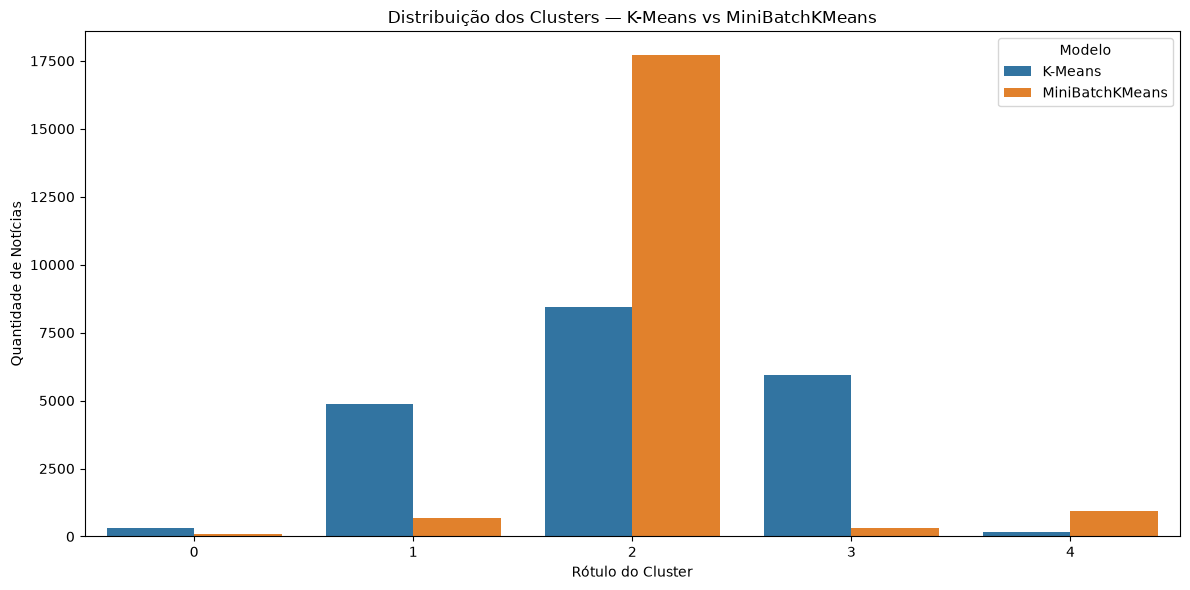

In [50]:
comparacao_clusters_plot = comparacao_clusters.reset_index()

comparacao_clusters_plot = comparacao_clusters_plot.rename(
    columns={"index": "Cluster"}
)

comparacao_clusters_plot = comparacao_clusters_plot.melt(
    id_vars="Cluster",
    var_name="Modelo",
    value_name="Quantidade"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=comparacao_clusters_plot,
    x="Cluster",
    y="Quantidade",
    hue="Modelo"
)

plt.title("Distribuição dos Clusters — K-Means vs MiniBatchKMeans")
plt.xlabel("Rótulo do Cluster")
plt.ylabel("Quantidade de Notícias")

plt.tight_layout()
plt.show()

DBSCAN

In [51]:
eps_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

resultados_dbscan = []

for eps in eps_values:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=10
    )

    labels = dbscan.fit_predict(X_reduced)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()

    resultados_dbscan.append({
        "eps": eps,
        "clusters": n_clusters,
        "ruido": n_noise,
        "percentual_ruido": n_noise / len(labels) * 100
    })

resultados_dbscan = pd.DataFrame(resultados_dbscan)

print(resultados_dbscan)

   eps  clusters  ruido  percentual_ruido
0  0.1         5  19665         99.569620
1  0.2        43  15096         76.435443
2  0.3        12   1872          9.478481
3  0.4         5     10          0.050633
4  0.5         4      0          0.000000
5  0.6         3      0          0.000000
6  0.7         1      0          0.000000
7  0.8         1      0          0.000000


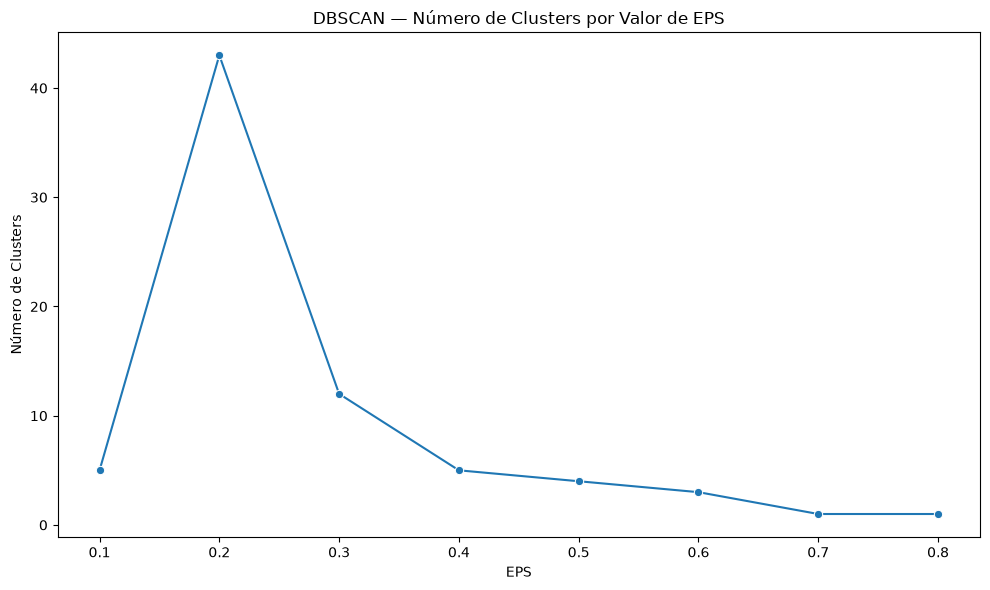

In [52]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=resultados_dbscan,
    x="eps",
    y="clusters",
    marker="o"
)

plt.title("DBSCAN — Número de Clusters por Valor de EPS")
plt.xlabel("EPS")
plt.ylabel("Número de Clusters")

plt.xticks(resultados_dbscan["eps"])

plt.tight_layout()
plt.show()

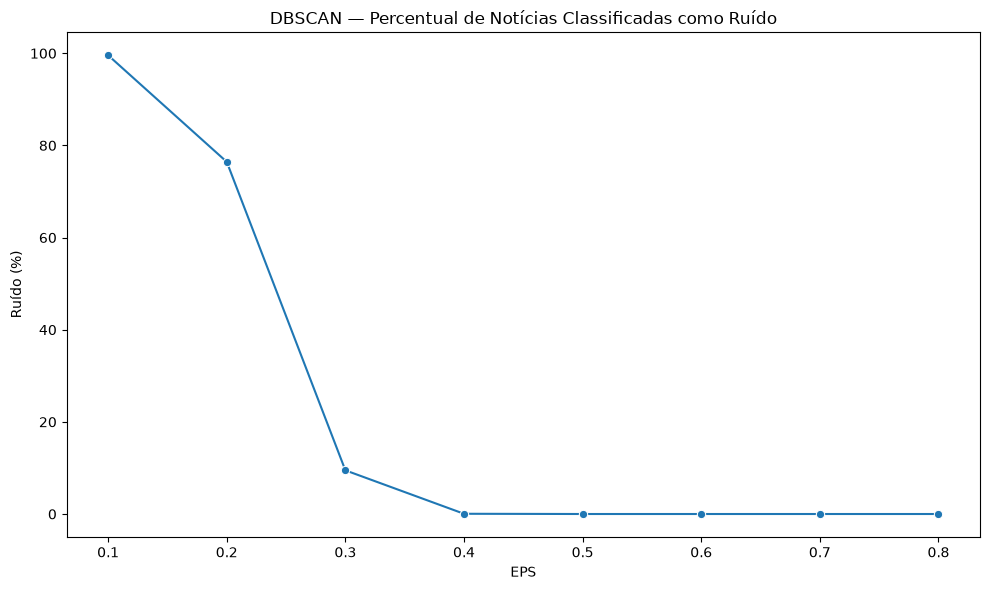

In [53]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=resultados_dbscan,
    x="eps",
    y="percentual_ruido",
    marker="o"
)

plt.title("DBSCAN — Percentual de Notícias Classificadas como Ruído")
plt.xlabel("EPS")
plt.ylabel("Ruído (%)")

plt.xticks(resultados_dbscan["eps"])

plt.tight_layout()
plt.show()

In [54]:
dbscan_final = DBSCAN(
    eps=0.3,
    min_samples=10
)

finews_limpo["cluster_dbscan"] = dbscan_final.fit_predict(
    X_reduced
)

print("Distribuição dos clusters — DBSCAN:")
print(
    finews_limpo["cluster_dbscan"]
    .value_counts()
    .sort_index()
)

Distribuição dos clusters — DBSCAN:
cluster_dbscan
-1      1872
 0     17051
 1        20
 2        18
 3        41
 4        96
 5        23
 6       178
 7        54
 8        15
 9        46
 10      300
 11       36
Name: count, dtype: int64


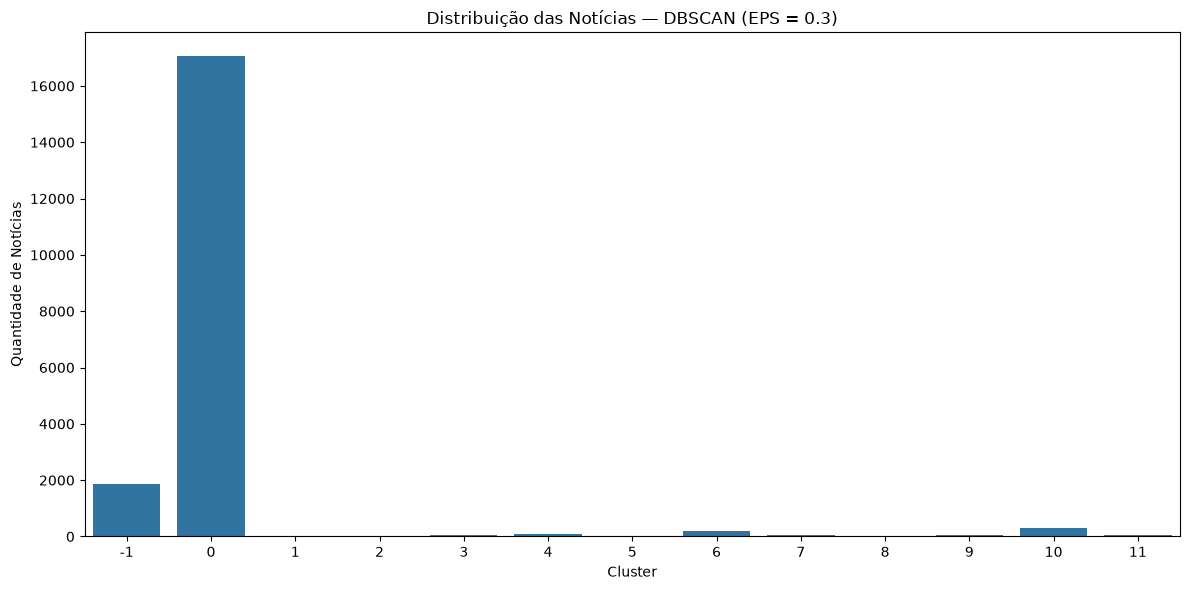

In [55]:
contagem_dbscan = (
    finews_limpo["cluster_dbscan"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=contagem_dbscan.index.astype(str),
    y=contagem_dbscan.values
)

plt.title("Distribuição das Notícias — DBSCAN (EPS = 0.3)")
plt.xlabel("Cluster")
plt.ylabel("Quantidade de Notícias")

plt.tight_layout()
plt.show()

In [56]:
ruido_dbscan = (finews_limpo["cluster_dbscan"] == -1).sum()
total_noticias = len(finews_limpo)

percentual_ruido = ruido_dbscan / total_noticias * 100

print(f"Notícias classificadas como ruído: {ruido_dbscan}")
print(f"Total de notícias: {total_noticias}")
print(f"Percentual de ruído: {percentual_ruido:.2f}%")

Notícias classificadas como ruído: 1872
Total de notícias: 19750
Percentual de ruído: 9.48%


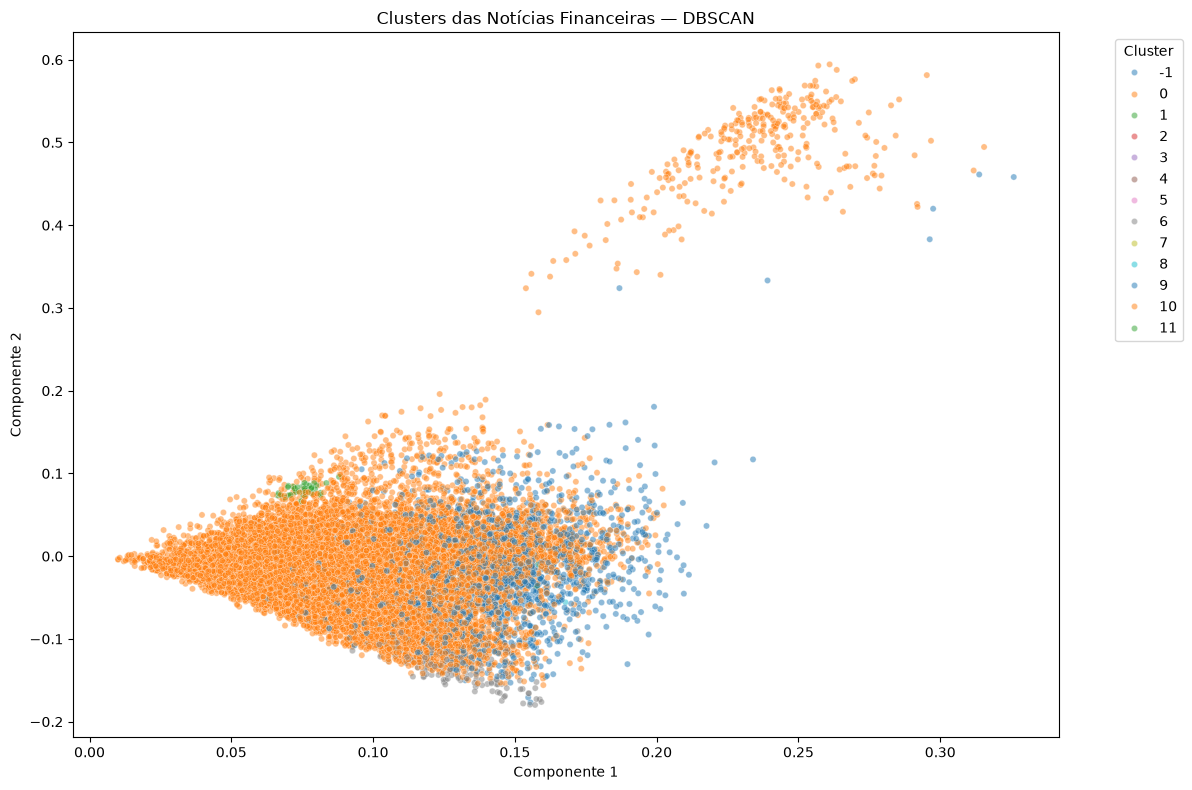

In [57]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    x=X_2d[:, 0],
    y=X_2d[:, 1],
    hue=finews_limpo["cluster_dbscan"],
    palette="tab10",
    s=20,
    alpha=0.5,
    legend="full"
)

plt.title("Clusters das Notícias Financeiras — DBSCAN")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")

plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

Gaussian Mixture

In [58]:
resultados_gmm = []

for n in range(2, 11):

    gmm = GaussianMixture(
        n_components=n,
        random_state=42
    )

    gmm.fit(X_reduced)

    resultados_gmm.append({
        "componentes": n,
        "AIC": gmm.aic(X_reduced),
        "BIC": gmm.bic(X_reduced)
    })

resultados_gmm = pd.DataFrame(resultados_gmm)

print(resultados_gmm)

   componentes           AIC           BIC
0            2 -8.374549e+06 -8.293265e+06
1            3 -8.420702e+06 -8.298772e+06
2            4 -8.836318e+06 -8.673741e+06
3            5 -8.917527e+06 -8.714304e+06
4            6 -9.183669e+06 -8.939800e+06
5            7 -9.256431e+06 -8.971916e+06
6            8 -9.433866e+06 -9.108706e+06
7            9 -9.517134e+06 -9.151327e+06
8           10 -9.663920e+06 -9.257468e+06


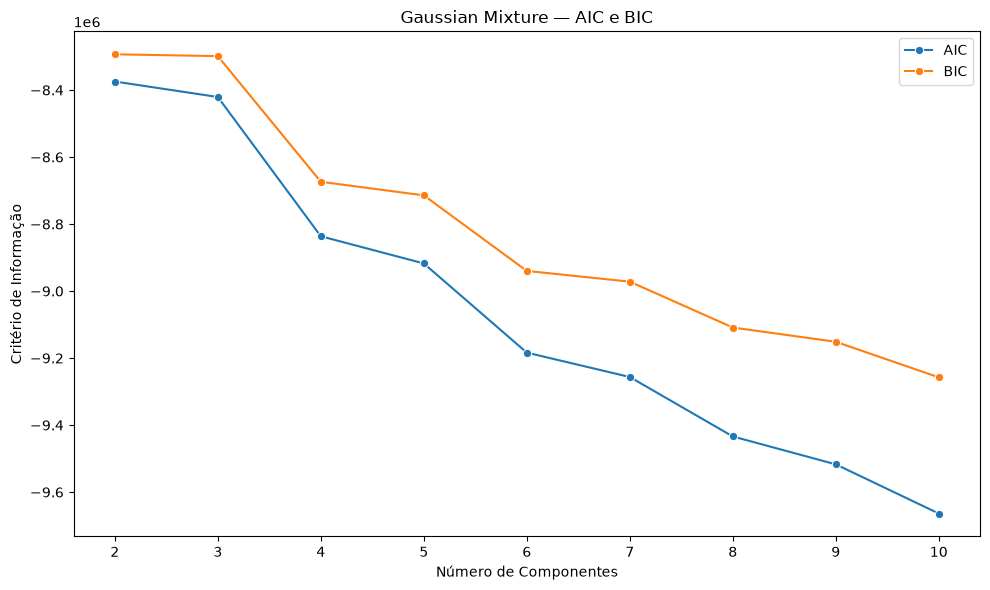

In [59]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=resultados_gmm,
    x="componentes",
    y="AIC",
    marker="o",
    label="AIC"
)

sns.lineplot(
    data=resultados_gmm,
    x="componentes",
    y="BIC",
    marker="o",
    label="BIC"
)

plt.title("Gaussian Mixture — AIC e BIC")
plt.xlabel("Número de Componentes")
plt.ylabel("Critério de Informação")

plt.xticks(resultados_gmm["componentes"])
plt.legend()

plt.tight_layout()
plt.show()

In [83]:
resultados_gmm = []

for n in range(2, 13):

    print(f"Testando {n} componentes...")

    gmm = GaussianMixture(
        n_components=n,
        covariance_type="diag",
        n_init=2,
        max_iter=300,
        random_state=42
    )

    gmm.fit(X_reduced)

    resultados_gmm.append({
        "componentes": n,
        "AIC": gmm.aic(X_reduced),
        "BIC": gmm.bic(X_reduced),
        "convergiu": gmm.converged_
    })

resultados_gmm = pd.DataFrame(resultados_gmm)

print(resultados_gmm)

Testando 2 componentes...
Testando 3 componentes...
Testando 4 componentes...
Testando 5 componentes...
Testando 6 componentes...
Testando 7 componentes...
Testando 8 componentes...
Testando 9 componentes...
Testando 10 componentes...
Testando 11 componentes...
Testando 12 componentes...
    componentes           AIC           BIC  convergiu
0             2 -7.701597e+06 -7.698433e+06       True
1             3 -7.790858e+06 -7.786108e+06       True
2             4 -7.811916e+06 -7.805579e+06       True
3             5 -7.847177e+06 -7.839254e+06       True
4             6 -7.873169e+06 -7.863660e+06       True
5             7 -7.909533e+06 -7.898439e+06       True
6             8 -7.924399e+06 -7.911719e+06       True
7             9 -7.963807e+06 -7.949540e+06       True
8            10 -7.974200e+06 -7.958348e+06       True
9            11 -7.994800e+06 -7.977361e+06       True
10           12 -8.032796e+06 -8.013771e+06       True


In [84]:
resultados_gmm

,componentes,AIC,BIC,convergiu
0,2,-7.701597e+06,-7.698433e+06,True
1,3,-7.790858e+06,-7.786108e+06,True
2,4,-7.811916e+06,-7.805579e+06,True
3,5,-7.847177e+06,-7.839254e+06,True
4,6,-7.873169e+06,-7.863660e+06,True
5,7,-7.909533e+06,-7.898439e+06,True
6,8,-7.924399e+06,-7.911719e+06,True
7,9,-7.963807e+06,-7.949540e+06,True
8,10,-7.974200e+06,-7.958348e+06,True
9,11,-7.994800e+06,-7.977361e+06,True


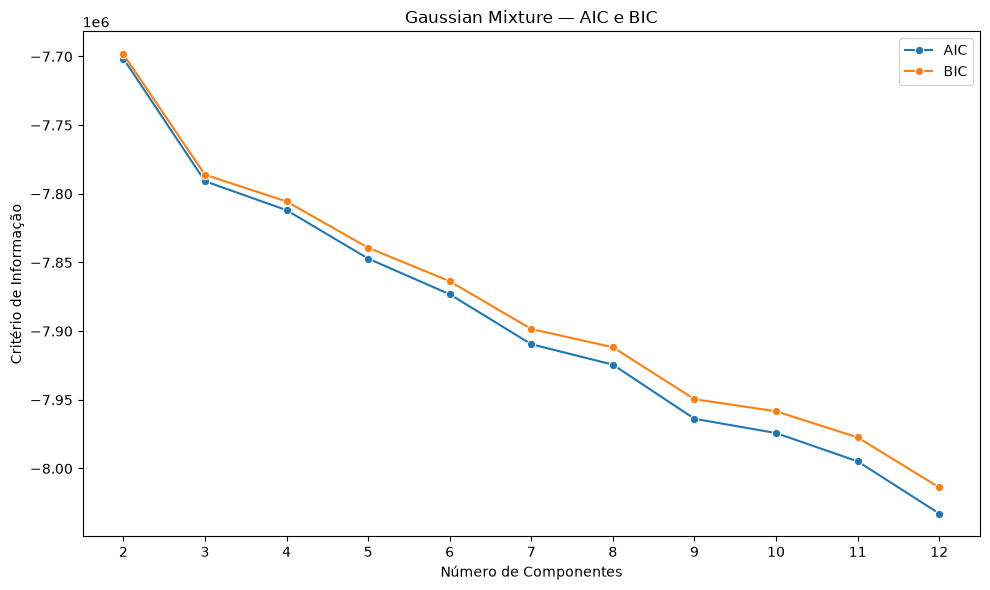

In [85]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=resultados_gmm,
    x="componentes",
    y="AIC",
    marker="o",
    label="AIC"
)

sns.lineplot(
    data=resultados_gmm,
    x="componentes",
    y="BIC",
    marker="o",
    label="BIC"
)

plt.title("Gaussian Mixture — AIC e BIC")
plt.xlabel("Número de Componentes")
plt.ylabel("Critério de Informação")
plt.xticks(resultados_gmm["componentes"])
plt.legend()
plt.tight_layout()
plt.show()

In [86]:
print(resultados_gmm[["componentes", "convergiu"]])

    componentes  convergiu
0             2       True
1             3       True
2             4       True
3             5       True
4             6       True
5             7       True
6             8       True
7             9       True
8            10       True
9            11       True
10           12       True


In [87]:
gmm_final = GaussianMixture(
    n_components=5,
    covariance_type="diag",
    n_init=3,
    max_iter=300,
    random_state=42
)

labels_gmm = gmm_final.fit_predict(X_reduced)

finews_limpo["cluster_gmm"] = labels_gmm

In [88]:
print(
    finews_limpo["cluster_gmm"]
    .value_counts()
    .sort_index()
)

cluster_gmm
0     328
1    9412
2     299
3    5773
4    3938
Name: count, dtype: int64


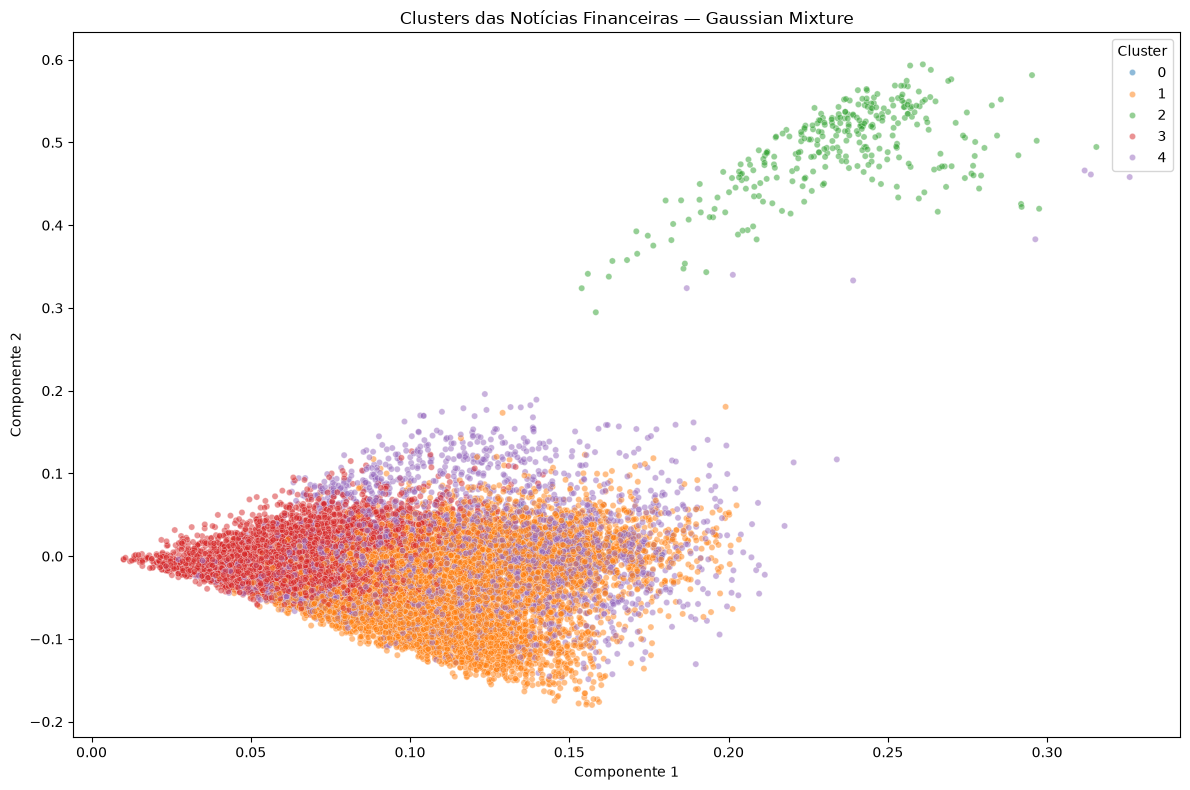

In [89]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    x=X_2d[:, 0],
    y=X_2d[:, 1],
    hue=finews_limpo["cluster_gmm"],
    palette="tab10",
    s=20,
    alpha=0.5,
    legend="full"
)

plt.title("Clusters das Notícias Financeiras — Gaussian Mixture")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

Isolation Forest

In [61]:
isolation_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

labels_if = isolation_forest.fit_predict(X_reduced)

finews_limpo["anomaly_if"] = labels_if

In [62]:
print(
    finews_limpo["anomaly_if"]
    .value_counts()
    .sort_index()
)

anomaly_if
-1      988
 1    18762
Name: count, dtype: int64


In [63]:
finews_limpo["tipo_anomalia"] = finews_limpo["anomaly_if"].map({
    1: "Normal",
    -1: "Anomalia"
})

In [64]:
print(
    finews_limpo["tipo_anomalia"]
    .value_counts()
)

tipo_anomalia
Normal      18762
Anomalia      988
Name: count, dtype: int64


In [65]:
quantidade_anomalias = (
    finews_limpo["anomaly_if"] == -1
).sum()

total_noticias = len(finews_limpo)

percentual_anomalias = (
    quantidade_anomalias / total_noticias
) * 100

print(f"Total de notícias: {total_noticias}")
print(f"Anomalias: {quantidade_anomalias}")
print(f"Percentual de anomalias: {percentual_anomalias:.2f}%")

Total de notícias: 19750
Anomalias: 988
Percentual de anomalias: 5.00%


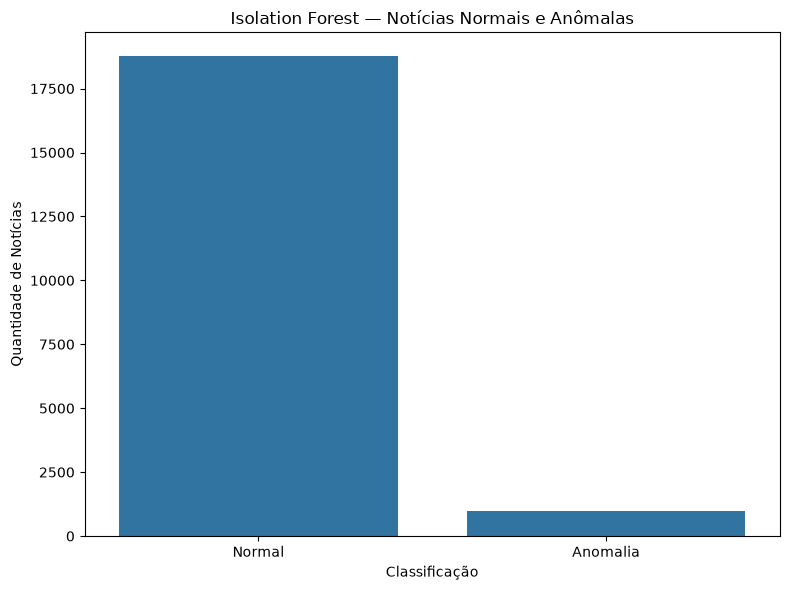

In [66]:
plt.figure(figsize=(8, 6))

contagem_anomalias = (
    finews_limpo["tipo_anomalia"]
    .value_counts()
)

sns.barplot(
    x=contagem_anomalias.index,
    y=contagem_anomalias.values
)

plt.title("Isolation Forest — Notícias Normais e Anômalas")
plt.xlabel("Classificação")
plt.ylabel("Quantidade de Notícias")

plt.tight_layout()
plt.show()

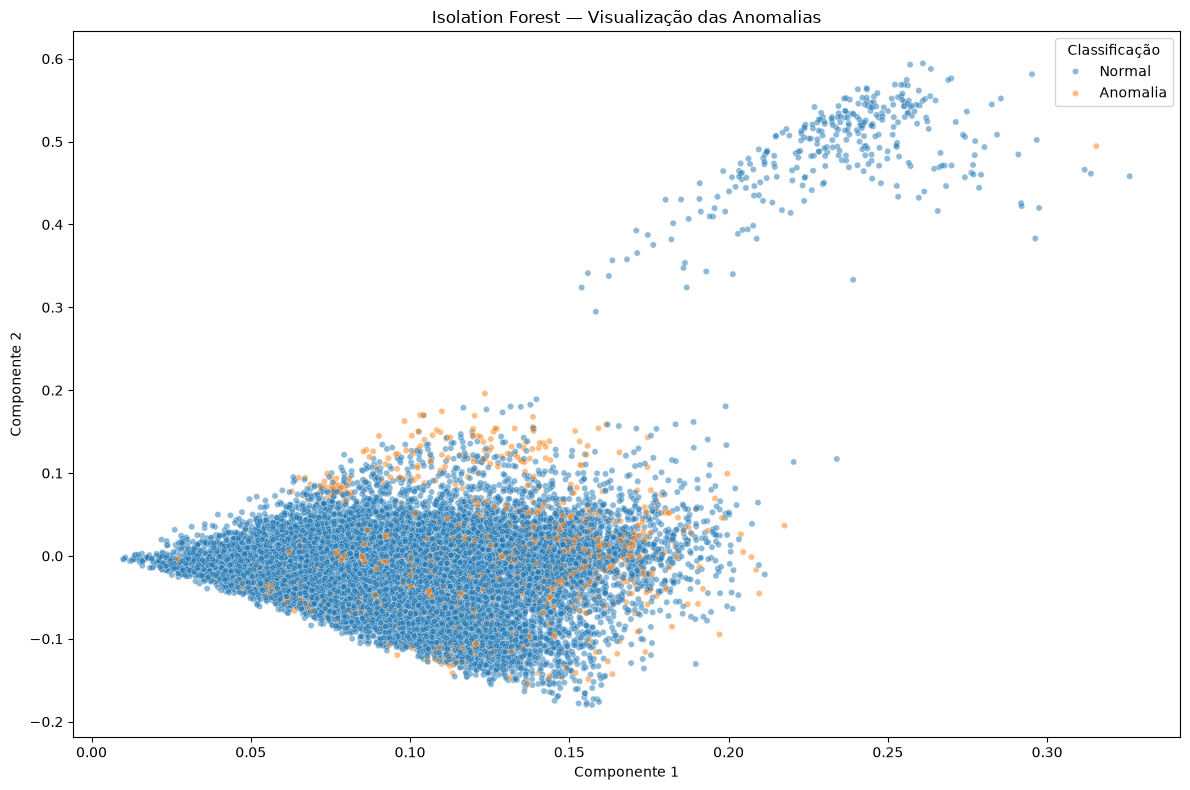

In [67]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    x=X_2d[:, 0],
    y=X_2d[:, 1],
    hue=finews_limpo["tipo_anomalia"],
    s=20,
    alpha=0.5
)

plt.title("Isolation Forest — Visualização das Anomalias")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")

plt.legend(title="Classificação")

plt.tight_layout()
plt.show()

In [68]:
scores_if = isolation_forest.decision_function(X_reduced)

finews_limpo["score_anomalia"] = scores_if

In [69]:
print(
    finews_limpo[
        ["title", "score_anomalia", "tipo_anomalia"]
    ].head(10)
)

                                                title  score_anomalia  \
3   Presença de Murilo Ferreira na Petrobras incom...        0.106584   
5   13 ações caem mais de 5%, Petrobras sobe 2% e ...       -0.006273   
8   Focus "estreia" 2016 projetando queda maior no...        0.067772   
10  Focus prevê mais inflação e maior retração eco...        0.085664   
11  IPCA para 2016 sobe de 6,86% para 6,87%, apont...        0.057756   
14  Ibovespa levou uma verdadeira goleada da renda...        0.043520   
16  Produção de petróleo do Brasil cai 1,1% em nov...        0.080246   
18  Dólar salta 2% e vai acima de R$ 4 com dados f...        0.064517   
30  Bovespa fecha em queda com aversão ao risco po...        0.026564   
33  Dólar sobe a R$4,0339, maior cotação desde set...        0.062633   

   tipo_anomalia  
3         Normal  
5       Anomalia  
8         Normal  
10        Normal  
11        Normal  
14        Normal  
16        Normal  
18        Normal  
30        Normal  
33    

In [70]:
noticias_anomalas = (
    finews_limpo[
        finews_limpo["anomaly_if"] == -1
    ]
    .sort_values("score_anomalia")
)

print(
    noticias_anomalas[
        ["title", "source", "published_at", "score_anomalia"]
    ].head(20)
)

                                                   title           source  \
9486   Ibovespa tem dia volátil e fecha perto da esta...  Valor Econômico   
9577   Dólar e juros futuros revertem alta e caem apó...  Valor Econômico   
9868   Ibovespa oscila perto da estabilidade em dia d...  Valor Econômico   
37543  Decisões de Copom e Fed: o que esperar da prim...            Exame   
9031   Um dia após bater recorde, Ibovespa mostra men...  Valor Econômico   
9358   Após leilões, Tesouro garante liberação de R$ ...  Valor Econômico   
2669   Ibovespa fecha em leve alta com melhora de com...            Exame   
9698   Dólar e juros futuros operam perto da estabili...  Valor Econômico   
9759   Bolsa cai e dólar chega perto de R$ 3,20 nesta...  Valor Econômico   
50857  Prévia do PIB: IBC-Br sobe 0,8% em março, acim...            Exame   
8856            Qualicorp recua na B3 após ação judicial  Valor Econômico   
9556               Dólar cai ante o real após ata do Fed  Valor Econômico   

In [71]:
for _, noticia in noticias_anomalas.head(10).iterrows():
    print("=" * 80)
    print("Título:", noticia["title"])
    print("Fonte:", noticia["source"])
    print("Data:", noticia["published_at"])
    print("Score:", noticia["score_anomalia"])

Título: Ibovespa tem dia volátil e fecha perto da estabilidade
Fonte: Valor Econômico
Data: 2017-10-05 20:49:39+00:00
Score: -0.08533718192587209
Título: Dólar e juros futuros revertem alta e caem após dados dos EUA
Fonte: Valor Econômico
Data: 2017-10-13 13:29:33+00:00
Score: -0.08305831707444283
Título: Ibovespa oscila perto da estabilidade em dia de balanços; dólar sobe
Fonte: Valor Econômico
Data: 2017-10-26 18:04:45+00:00
Score: -0.08226360763720159
Título: Decisões de Copom e Fed: o que esperar da primeira Super Quarta do ano
Fonte: Exame
Data: 2023-02-01 06:03:54+00:00
Score: -0.07957287932772655
Título: Um dia após bater recorde, Ibovespa mostra menos força
Fonte: Valor Econômico
Data: 2017-09-12 13:59:19+00:00
Score: -0.07745697222111564
Título: Após leilões, Tesouro garante liberação de R$ 12,8 bi neste ano
Fonte: Valor Econômico
Data: 2017-09-29 08:00:01+00:00
Score: -0.07720933125465862
Título: Ibovespa fecha em leve alta com melhora de commodities
Fonte: Exame
Data: 2016-0

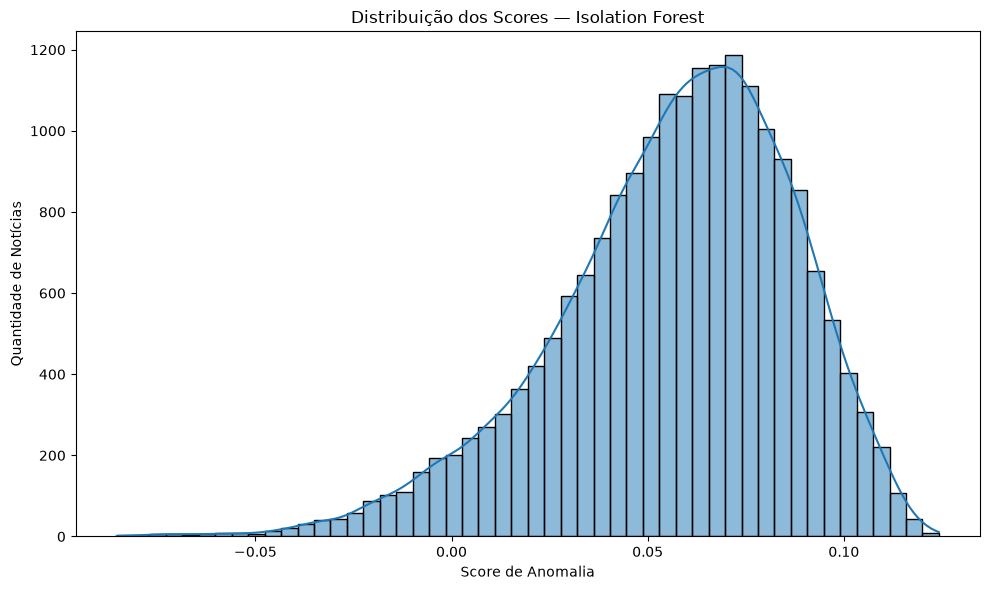

In [72]:
plt.figure(figsize=(10, 6))

sns.histplot(
    finews_limpo["score_anomalia"],
    bins=50,
    kde=True
)

plt.title("Distribuição dos Scores — Isolation Forest")
plt.xlabel("Score de Anomalia")
plt.ylabel("Quantidade de Notícias")

plt.tight_layout()
plt.show()

In [73]:
print(finews_limpo["anomaly_if"].value_counts().sort_index())

anomaly_if
-1      988
 1    18762
Name: count, dtype: int64


In [74]:
print(
    finews_limpo[
        ["title", "source", "published_at", "score_anomalia"]
    ]
    .sort_values("score_anomalia")
    .head(20)
)

                                                   title           source  \
9486   Ibovespa tem dia volátil e fecha perto da esta...  Valor Econômico   
9577   Dólar e juros futuros revertem alta e caem apó...  Valor Econômico   
9868   Ibovespa oscila perto da estabilidade em dia d...  Valor Econômico   
37543  Decisões de Copom e Fed: o que esperar da prim...            Exame   
9031   Um dia após bater recorde, Ibovespa mostra men...  Valor Econômico   
9358   Após leilões, Tesouro garante liberação de R$ ...  Valor Econômico   
2669   Ibovespa fecha em leve alta com melhora de com...            Exame   
9698   Dólar e juros futuros operam perto da estabili...  Valor Econômico   
9759   Bolsa cai e dólar chega perto de R$ 3,20 nesta...  Valor Econômico   
50857  Prévia do PIB: IBC-Br sobe 0,8% em março, acim...            Exame   
8856            Qualicorp recua na B3 após ação judicial  Valor Econômico   
9556               Dólar cai ante o real após ata do Fed  Valor Econômico   

In [75]:
anomalias = finews_limpo[
    finews_limpo["anomaly_if"] == -1
]

print(
    anomalias["source"]
    .value_counts()
)

source
InfoMoney          370
Exame              319
Valor Econômico    299
Name: count, dtype: int64


In [76]:
print(
    anomalias["year"]
    .value_counts()
    .sort_index()
)

year
2016    104
2017    107
2018     25
2019     49
2020     57
2021     64
2022    100
2023    113
2024    151
2025    218
Name: count, dtype: int64


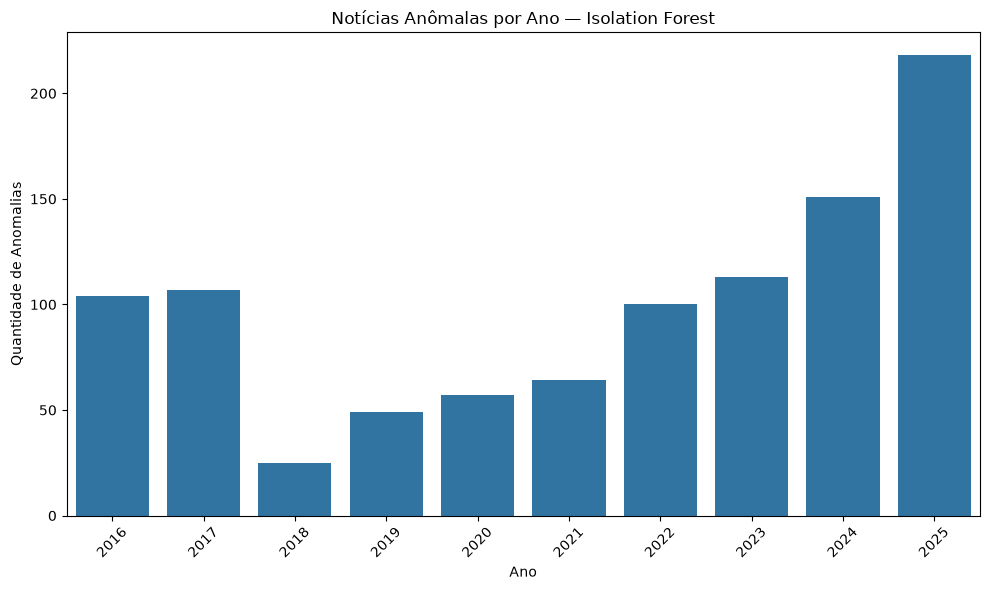

In [77]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=anomalias,
    x="year"
)

plt.title("Notícias Anômalas por Ano — Isolation Forest")
plt.xlabel("Ano")
plt.ylabel("Quantidade de Anomalias")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [78]:
top_anomalias = (
    finews_limpo[
        finews_limpo["anomaly_if"] == -1
    ]
    .sort_values("score_anomalia")
    .head(20)
)

top_anomalias[
    [
        "title",
        "source",
        "published_at",
        "score_anomalia"
    ]
]

,title,source,published_at,score_anomalia
9486,Ibovespa tem dia volátil e fecha perto da esta...,Valor Econômico,2017-10-05 20:49:39+00:00,-0.085337
9577,Dólar e juros futuros revertem alta e caem apó...,Valor Econômico,2017-10-13 13:29:33+00:00,-0.083058
9868,Ibovespa oscila perto da estabilidade em dia d...,Valor Econômico,2017-10-26 18:04:45+00:00,-0.082264
37543,Decisões de Copom e Fed: o que esperar da prim...,Exame,2023-02-01 06:03:54+00:00,-0.079573
9031,"Um dia após bater recorde, Ibovespa mostra men...",Valor Econômico,2017-09-12 13:59:19+00:00,-0.077457
9358,"Após leilões, Tesouro garante liberação de R$ ...",Valor Econômico,2017-09-29 08:00:01+00:00,-0.077209
2669,Ibovespa fecha em leve alta com melhora de com...,Exame,2016-07-06 17:40:11+00:00,-0.074948
9698,Dólar e juros futuros operam perto da estabili...,Valor Econômico,2017-10-20 14:23:34+00:00,-0.074574
9759,"Bolsa cai e dólar chega perto de R$ 3,20 nesta...",Valor Econômico,2017-10-23 15:11:23+00:00,-0.074469
50857,"Prévia do PIB: IBC-Br sobe 0,8% em março, acim...",Exame,2025-05-19 09:13:06+00:00,-0.073688


In [79]:
for _, noticia in top_anomalias.iterrows():

    print("=" * 100)

    print("Título:")
    print(noticia["title"])

    print("\nDescrição:")
    print(noticia["description"])

    print("\nFonte:", noticia["source"])
    print("Data:", noticia["published_at"])
    print("Score:", noticia["score_anomalia"])

Título:
Ibovespa tem dia volátil e fecha perto da estabilidade

Descrição:
Taiwan entra em alerta após avistar navios de guerra chineses perto de suas ilhas Penghu

Fonte: Valor Econômico
Data: 2017-10-05 20:49:39+00:00
Score: -0.08533718192587209
Título:
Dólar e juros futuros revertem alta e caem após dados dos EUA

Descrição:
Taiwan entra em alerta após avistar navios de guerra chineses perto de suas ilhas Penghu

Fonte: Valor Econômico
Data: 2017-10-13 13:29:33+00:00
Score: -0.08305831707444283
Título:
Ibovespa oscila perto da estabilidade em dia de balanços; dólar sobe

Descrição:
Taiwan entra em alerta após avistar navios de guerra chineses perto de suas ilhas Penghu

Fonte: Valor Econômico
Data: 2017-10-26 18:04:45+00:00
Score: -0.08226360763720159
Título:
Decisões de Copom e Fed: o que esperar da primeira Super Quarta do ano

Descrição:
Bancos centrais do Brasil e dos Estados Unidos divulgam decisão de política monetária nesta quarta-feira

Fonte: Exame
Data: 2023-02-01 06:03:54

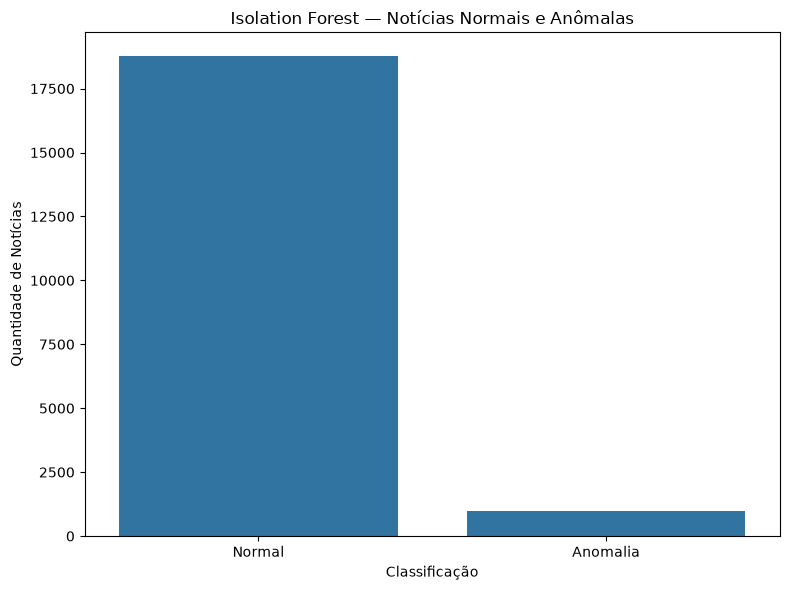

In [80]:
contagem_if = (
    finews_limpo["tipo_anomalia"]
    .value_counts()
    .reindex(["Normal", "Anomalia"])
)

plt.figure(figsize=(8, 6))

sns.barplot(
    x=contagem_if.index,
    y=contagem_if.values
)

plt.title("Isolation Forest — Notícias Normais e Anômalas")
plt.xlabel("Classificação")
plt.ylabel("Quantidade de Notícias")

plt.tight_layout()
plt.show()

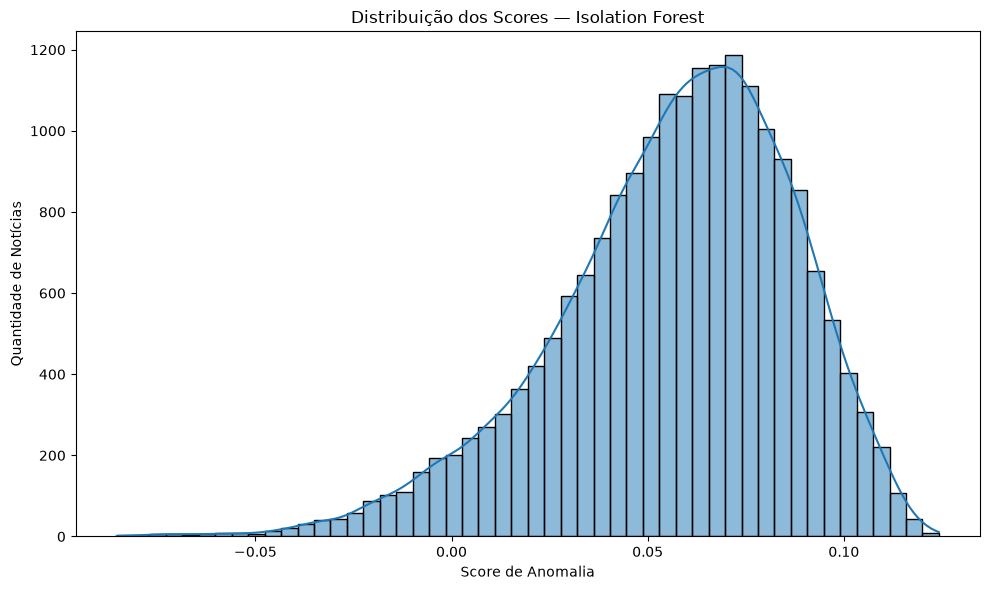

In [81]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=finews_limpo,
    x="score_anomalia",
    bins=50,
    kde=True
)

plt.title("Distribuição dos Scores — Isolation Forest")
plt.xlabel("Score de Anomalia")
plt.ylabel("Quantidade de Notícias")

plt.tight_layout()
plt.show()

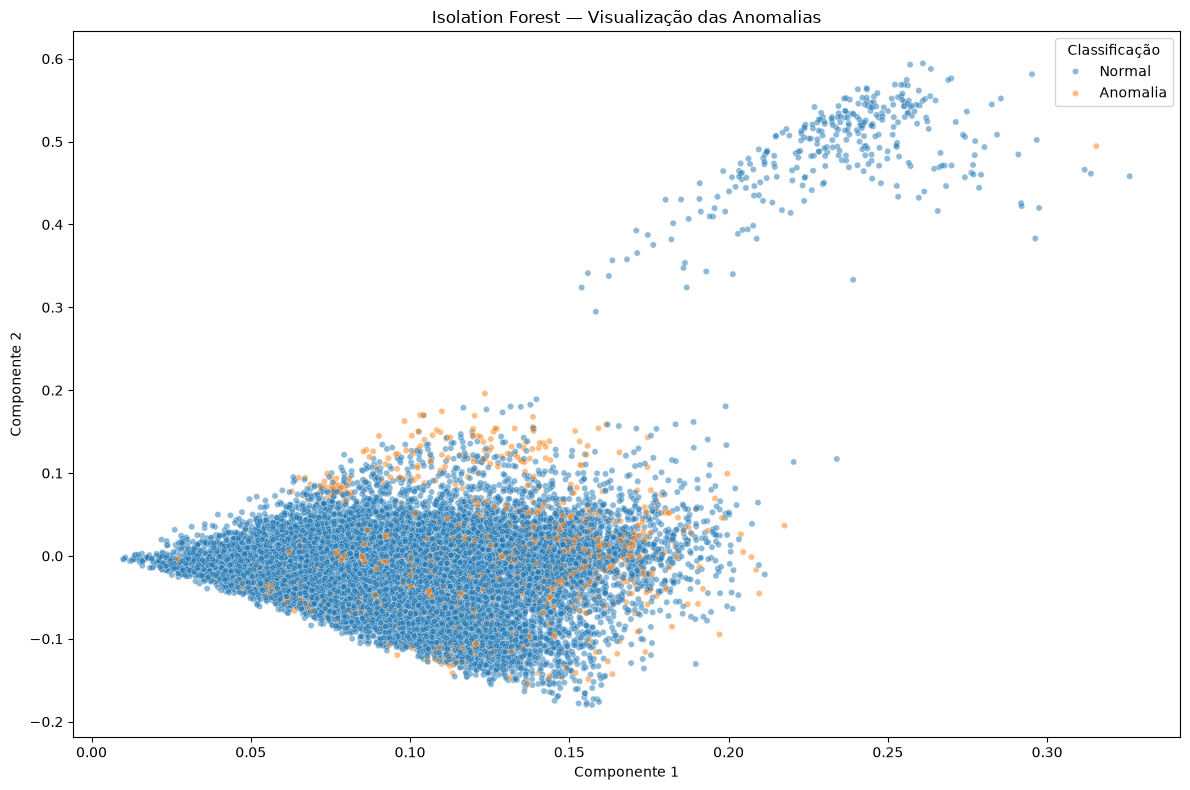

In [82]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    x=X_2d[:, 0],
    y=X_2d[:, 1],
    hue=finews_limpo["tipo_anomalia"],
    s=20,
    alpha=0.5
)

plt.title("Isolation Forest — Visualização das Anomalias")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")

plt.legend(title="Classificação")

plt.tight_layout()
plt.show()

Comparação dos 5 Modelos

In [90]:
comparacao_modelos = pd.DataFrame({
    "Modelo": [
        "K-Means",
        "MiniBatchKMeans",
        "DBSCAN",
        "Gaussian Mixture",
        "Isolation Forest"
    ],
    "Tipo": [
        "Clustering",
        "Clustering",
        "Clustering",
        "Clustering probabilístico",
        "Detecção de anomalias"
    ],
    "Resultado": [
        "5 clusters",
        "5 clusters",
        "12 clusters + ruído",
        "5 componentes",
        "988 anomalias / 18.762 normais"
    ],
    "Silhouette": [
        0.0475,
        0.0420,
        None,
        None,
        None
    ],
    "Observação": [
        "Clusters desbalanceados",
        "Grande concentração em um único cluster",
        "Identificou grupos densos e observações fora deles",
        "Clusters desbalanceados",
        "5% das observações classificadas como anomalias"
    ]
})

comparacao_modelos

,Modelo,Tipo,Resultado,Silhouette,Observação
0,K-Means,Clustering,5 clusters,0.0475,Clusters desbalanceados
1,MiniBatchKMeans,Clustering,5 clusters,0.0420,Grande concentração em um único cluster
2,DBSCAN,Clustering,12 clusters + ruído,NaN,Identificou grupos densos e observações fora d...
3,Gaussian Mixture,Clustering probabilístico,5 componentes,NaN,Clusters desbalanceados
4,Isolation Forest,Detecção de anomalias,988 anomalias / 18.762 normais,NaN,5% das observações classificadas como anomalias


In [91]:
finews_limpo["tipo_anomalia"].value_counts()

tipo_anomalia
Normal      18762
Anomalia      988
Name: count, dtype: int64

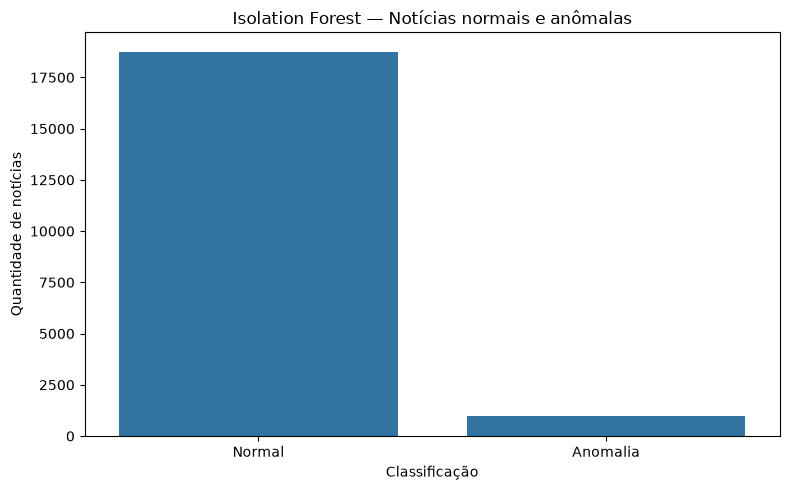

In [92]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=finews_limpo,
    x="tipo_anomalia"
)

plt.title("Isolation Forest — Notícias normais e anômalas")
plt.xlabel("Classificação")
plt.ylabel("Quantidade de notícias")
plt.tight_layout()
plt.show()

## Comparação dos modelos não supervisionados

Foram avaliados cinco métodos de aprendizado não supervisionado:
K-Means, MiniBatchKMeans, DBSCAN, Gaussian Mixture e Isolation Forest.

K-Means, MiniBatchKMeans, DBSCAN e Gaussian Mixture foram utilizados
para identificar estruturas e agrupamentos dentro das notícias financeiras.
Já o Isolation Forest foi utilizado para identificar observações
atípicas dentro da representação dos dados.

Os resultados dos métodos de agrupamento apresentaram grupos de tamanhos
bastante diferentes. K-Means e Gaussian Mixture produziram alguns grupos
maiores e outros menores, enquanto MiniBatchKMeans apresentou uma forte
concentração das notícias em um único cluster.

O DBSCAN identificou 12 grupos, considerando também o rótulo de ruído.
Nesse contexto, uma observação classificada como ruído não significa que
a notícia seja falsa ou menos confiável, mas apenas que ela não foi
associada a uma região de alta densidade segundo os parâmetros utilizados.

Os valores de Silhouette obtidos pelo K-Means (0,0475) e pelo
MiniBatchKMeans (0,0420) foram baixos, indicando pouca separação entre
os grupos na representação utilizada.

Para o Gaussian Mixture, os critérios AIC e BIC foram avaliados entre
2 e 12 componentes. Os dois critérios apresentaram redução contínua
nesse intervalo, não sendo identificado um ponto mínimo dentro da faixa
testada.

O Isolation Forest identificou 988 observações como anomalias e
18.762 como normais. Essas anomalias representam observações atípicas
na representação utilizada e não devem ser interpretadas como notícias
falsas.

De forma geral, os resultados mostram que as notícias financeiras
apresentam grande sobreposição na representação TF-IDF + SVD. Dessa
forma, os agrupamentos e anomalias identificados devem ser interpretados
como padrões exploratórios do conjunto de dados, e não como classificações
de veracidade das notícias.